Axel PORTIER, Lucas STALTER, Gaspard SALLURON--BESNARD

# Machine Learning Projet : Stock Return Prediction!

### Machine Learning Project | ESILV Financial Engineering IF5 | 2025/2026

# Project Overview

This project aims to predict the direction of residual stock returns in the U.S. market using historical financial data from Qube RT. The goal is to detect weak predictive signals rather than forecast exact prices, focusing on the underlying patterns that drive short-term stock movements once market effects are removed.

The dataset includes 46 numerical features, covering anonymized identifiers (`STOCK, INDUSTRY`, `SECTOR`) and 20-day histories of residual returns (`RET_1`–`RET_20`) and trading volumes (`VOLUME_1`–`VOLUME_20`). The target variable, `RET`, is binary, indicating whether the residual return at time t is positive or negative.

Following a structured machine learning pipeline, we perform data quality checks, feature preprocessing, and correlation analysis, then train both baseline models (e.g., Logistic Regression, Decision Trees) and advanced algorithms (e.g., Random Forest, XGBoost, Neural Networks). Model performance is assessed using F1-score and ROC-AUC, ensuring robust evaluation despite potential class imbalance.

Ultimately, this work explores how machine learning methods can capture meaningful financial patterns to support better decision-making in quantitative trading and risk management.

In [103]:
from pathlib import Path

import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

from sklearn.model_selection import KFold
import xgboost as xgb
from sklearn.linear_model import LogisticRegression
from sklearn.cross_decomposition import PLSRegression
from sklearn.ensemble import VotingClassifier, BaggingClassifier, StackingClassifier, RandomForestClassifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.svm import LinearSVC

from sklearn.ensemble import IsolationForest
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, roc_auc_score,log_loss, roc_curve
from scipy.stats import skew, kurtosis
from sklearn.metrics import make_scorer
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.base import clone

from scipy.stats import loguniform, randint

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression, Lasso, ElasticNet, BayesianRidge

import math

# First overall analysis of the dataset

The dataset consists of 46 descriptive features, all represented as numerical values (float or integer).

- `DATE` : an anonymized and randomized date index, without temporal continuity or sequential dependency.

- `STOCK` : an identifier representing the stock.

- `INDUSTRY`, `INDUSTRY_GROUP`, `SUB_INDUSTRY`, `SECTOR`: hierarchical categorical indices describing the economic domain of each stock (e.g., aeronautics, IT, oil, etc.).

- `RET_1` to `RET_20`: historical residual returns over the last 20 days, where `RET_1` corresponds to the previous day’s residual return, `RET_2` to two days before, and so on.

- `VOLUME_1` to `VOLUME_20`: historical relative trading volumes over the last 20 days, where `VOLUME_1` is the volume of the previous day.

The target variable, `RET`, is binary and represents the sign of the residual stock return at time t (i.e., positive or negative).

In the initial phase, the analysis focuses on understanding the dataset’s structure — specifically investigating missing values, class balance, and potential correlations among features.

### In the dataset we must acknowledge this : SUB INDUSTRY ⊂ INDUSTRY ⊂ INDUSTRY_GROUP ⊂ SECTOR 

# I) Data Loading & Initial Verification

In [2]:
x_train = pd.read_csv('./x_train.csv', index_col='ID')
y_train = pd.read_csv('./y_train.csv', index_col='ID')
train = pd.concat([x_train, y_train], axis=1) #axis = 1 concat by columns
test = pd.read_csv('./x_test.csv', index_col='ID')
ret_features = [f'RET_{day}' for day in range(1,21)]
vol_features = [f'VOLUME_{day}' for day in range(1,21)]
features = vol_features + ret_features
print(train.columns)
train.head()

Index(['DATE', 'STOCK', 'INDUSTRY', 'INDUSTRY_GROUP', 'SECTOR', 'SUB_INDUSTRY',
       'RET_1', 'VOLUME_1', 'RET_2', 'VOLUME_2', 'RET_3', 'VOLUME_3', 'RET_4',
       'VOLUME_4', 'RET_5', 'VOLUME_5', 'RET_6', 'VOLUME_6', 'RET_7',
       'VOLUME_7', 'RET_8', 'VOLUME_8', 'RET_9', 'VOLUME_9', 'RET_10',
       'VOLUME_10', 'RET_11', 'VOLUME_11', 'RET_12', 'VOLUME_12', 'RET_13',
       'VOLUME_13', 'RET_14', 'VOLUME_14', 'RET_15', 'VOLUME_15', 'RET_16',
       'VOLUME_16', 'RET_17', 'VOLUME_17', 'RET_18', 'VOLUME_18', 'RET_19',
       'VOLUME_19', 'RET_20', 'VOLUME_20', 'RET'],
      dtype='object')


,DATE,STOCK,INDUSTRY,INDUSTRY_GROUP,SECTOR,SUB_INDUSTRY,RET_1,VOLUME_1,RET_2,VOLUME_2,...,VOLUME_16,RET_17,VOLUME_17,RET_18,VOLUME_18,RET_19,VOLUME_19,RET_20,VOLUME_20,RET
ID,,,,,,,,,,,,,,,,,,,,,
0,0,2,18,5,3,44,-0.015748,0.147931,-0.015504,0.179183,...,0.630899,0.003254,-0.379412,0.008752,-0.110597,-0.012959,0.174521,-0.002155,-0.000937,True
1,0,3,43,15,6,104,0.003984,NaN,-0.090580,NaN,...,NaN,0.003774,NaN,-0.018518,NaN,-0.028777,NaN,-0.034722,NaN,True
2,0,4,57,20,8,142,0.000440,-0.096282,-0.058896,0.084771,...,-0.010336,-0.017612,-0.354333,-0.006562,-0.519391,-0.012101,-0.356157,-0.006867,-0.308868,False
3,0,8,1,1,1,2,0.031298,-0.429540,0.007756,-0.089919,...,0.012105,0.033824,-0.290178,-0.001468,-0.663834,-0.013520,-0.562126,-0.036745,-0.631458,False
4,0,14,36,12,5,92,0.027273,-0.847155,-0.039302,-0.943033,...,-0.277083,-0.012659,0.139086,0.004237,-0.017547,0.004256,0.579510,-0.040817,0.802806,False


### Dataset features's types

In [3]:
train.info()
train.dtypes.value_counts()

<class 'pandas.core.frame.DataFrame'>
Index: 418595 entries, 0 to 418594
Data columns (total 47 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            418595 non-null  int64  
 1   STOCK           418595 non-null  int64  
 2   INDUSTRY        418595 non-null  int64  
 3   INDUSTRY_GROUP  418595 non-null  int64  
 4   SECTOR          418595 non-null  int64  
 5   SUB_INDUSTRY    418595 non-null  int64  
 6   RET_1           416236 non-null  float64
 7   VOLUME_1        353570 non-null  float64
 8   RET_2           416130 non-null  float64
 9   VOLUME_2        352209 non-null  float64
 10  RET_3           416088 non-null  float64
 11  VOLUME_3        350776 non-null  float64
 12  RET_4           416051 non-null  float64
 13  VOLUME_4        347598 non-null  float64
 14  RET_5           416011 non-null  float64
 15  VOLUME_5        343902 non-null  float64
 16  RET_6           415998 non-null  float64
 17  VOLUME_6       

float64    40
int64       6
bool        1
Name: count, dtype: int64

### Type of the target

In [4]:
print(train['RET'].value_counts(normalize=True))
print(train['RET'].dtype)

RET
False    0.501079
True     0.498921
Name: proportion, dtype: float64
bool


The target variable `RET` is well balanced, with approximately 50.1% False and 49.9% True values, indicating no significant class imbalance in the dataset. However, to experiment with different approaches, we will still address the imbalance problem later in the project.

### Dataset's dimensions :

In [5]:
print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
train.head()
train.describe(include='all')

Train shape: (418595, 47)
Test shape: (198429, 46)


,DATE,STOCK,INDUSTRY,INDUSTRY_GROUP,SECTOR,SUB_INDUSTRY,RET_1,VOLUME_1,RET_2,VOLUME_2,...,VOLUME_16,RET_17,VOLUME_17,RET_18,VOLUME_18,RET_19,VOLUME_19,RET_20,VOLUME_20,RET
count,418595.000000,418595.000000,418595.000000,418595.000000,418595.000000,418595.000000,416236.000000,353570.000000,416130.000000,352209.000000,...,351333.000000,413294.000000,356281.000000,413288.000000,351009.000000,413282.000000,351266.000000,413254.000000,350738.000000,418595
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,209749
mean,108.659002,3373.567833,37.176020,12.697959,5.483845,90.391663,0.001383,-0.071502,0.000973,-0.075230,...,-0.076018,0.001642,-0.087854,0.001131,-0.076147,-0.000798,-0.076496,-0.000027,-0.076337,NaN
std,61.891642,1533.157749,19.706505,7.231701,2.410113,47.491157,0.031311,3.038658,0.030987,2.635549,...,2.185741,0.031914,2.094459,0.031435,2.423121,0.030738,2.229668,0.033347,2.721355,NaN
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.845324,-2.434414,-0.770751,-3.007262,...,-5.600056,-0.825014,-4.610393,-0.876157,-4.167784,-0.880000,-2.341887,-0.785714,-2.768928,NaN
25%,56.000000,2478.000000,22.000000,6.000000,4.000000,49.000000,-0.010970,-0.555394,-0.011312,-0.540629,...,-0.533574,-0.011331,-0.552613,-0.010949,-0.539491,-0.012139,-0.527846,-0.011682,-0.542790,NaN
50%,104.000000,3560.000000,43.000000,15.000000,6.000000,104.000000,0.000637,-0.282609,0.000401,-0.278437,...,-0.272271,0.000433,-0.285480,0.000000,-0.281753,0.000000,-0.277674,0.000000,-0.283405,NaN
75%,161.000000,4606.000000,53.000000,19.000000,7.000000,128.000000,0.012950,0.047759,0.012326,0.041177,...,0.029131,0.012862,0.027272,0.012180,0.027639,0.011236,0.030201,0.011712,0.035795,NaN


# II) Data Processing

### From now on, we are gonna work on the train by the intermediary of the ***cleaning_train*** dataset in order to clearly seperate both

In [6]:
cleaning_train = train.copy()

## II.1) Missing values analysis

### 1-A) MISSING VALUES FOR TRAIN

#### Missing values distribution for train

In [ ]:
cleaning_train.isna().sum(axis = 0)/len(cleaning_train)*100 # 

DATE               0.000000
STOCK              0.000000
INDUSTRY           0.000000
INDUSTRY_GROUP     0.000000
SECTOR             0.000000
SUB_INDUSTRY       0.000000
RET_1              0.563552
VOLUME_1          15.534108
RET_2              0.588875
VOLUME_2          15.859243
RET_3              0.598908
VOLUME_3          16.201579
RET_4              0.607747
VOLUME_4          16.960785
RET_5              0.617303
VOLUME_5          17.843739
RET_6              0.620409
VOLUME_6          17.848756
RET_7              0.617542
VOLUME_7          17.643068
RET_8              0.626620
VOLUME_8          17.653818
RET_9              0.640715
VOLUME_9          17.510481
RET_10             0.643104
VOLUME_10         17.512154
RET_11             0.707366
VOLUME_11         17.206369
RET_12             0.761118
VOLUME_12         14.936394
RET_13             0.802685
VOLUME_13         14.096681
RET_14             1.054241
VOLUME_14         14.555597
RET_15             1.192083
VOLUME_15         15

Percentage of nan values per feature (axis=0 : each nbr of nan for each features)

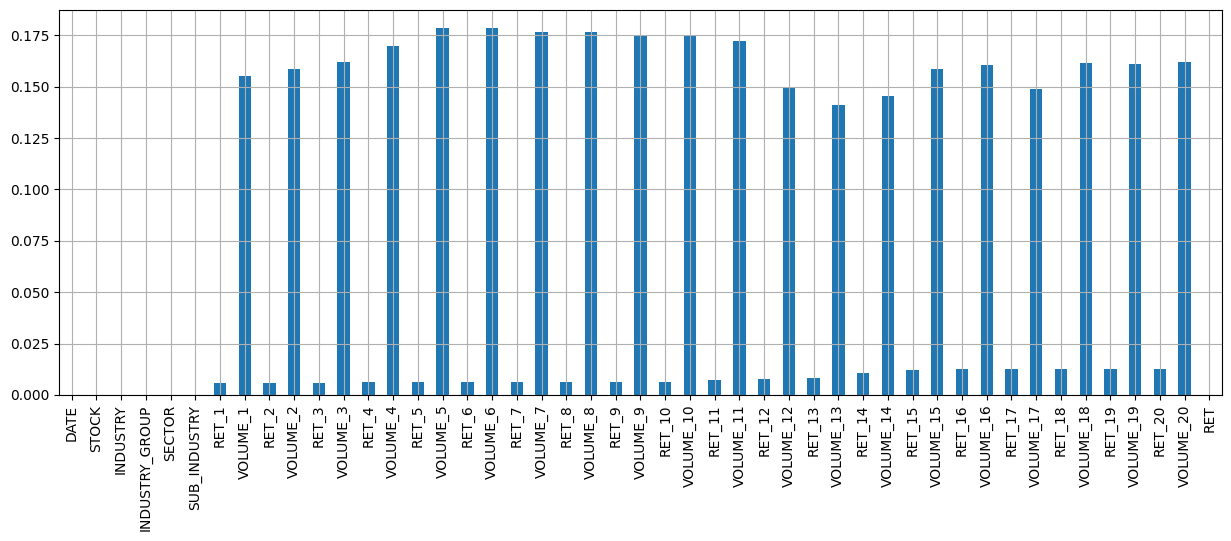

In [8]:
nb_missing = cleaning_train.isna().sum()
rate_missing = nb_missing / cleaning_train.index.nunique()

fig, ax = plt.subplots(figsize=(15,5))
rate_missing.plot(kind="bar", ax=ax)

ax.grid()
plt.xticks(rotation=90)
plt.show()


Most of the missing values are concentrated in the `VOLUME_1`..., with around **15% missing data**, which represents a considerable proportion. 
Consequently, a specific step will be devoted later to addressing these missing values.
It is also import to hightlight that there is no missing values in the `SECTOR` etc.

#### Percentage of missing values for each unique value within  `INDUSTRY`, `INDUSTRY_GROUP`, `SECTOR`, `SUB_INDUSTRY`, `STOCK`, and `DATE`.

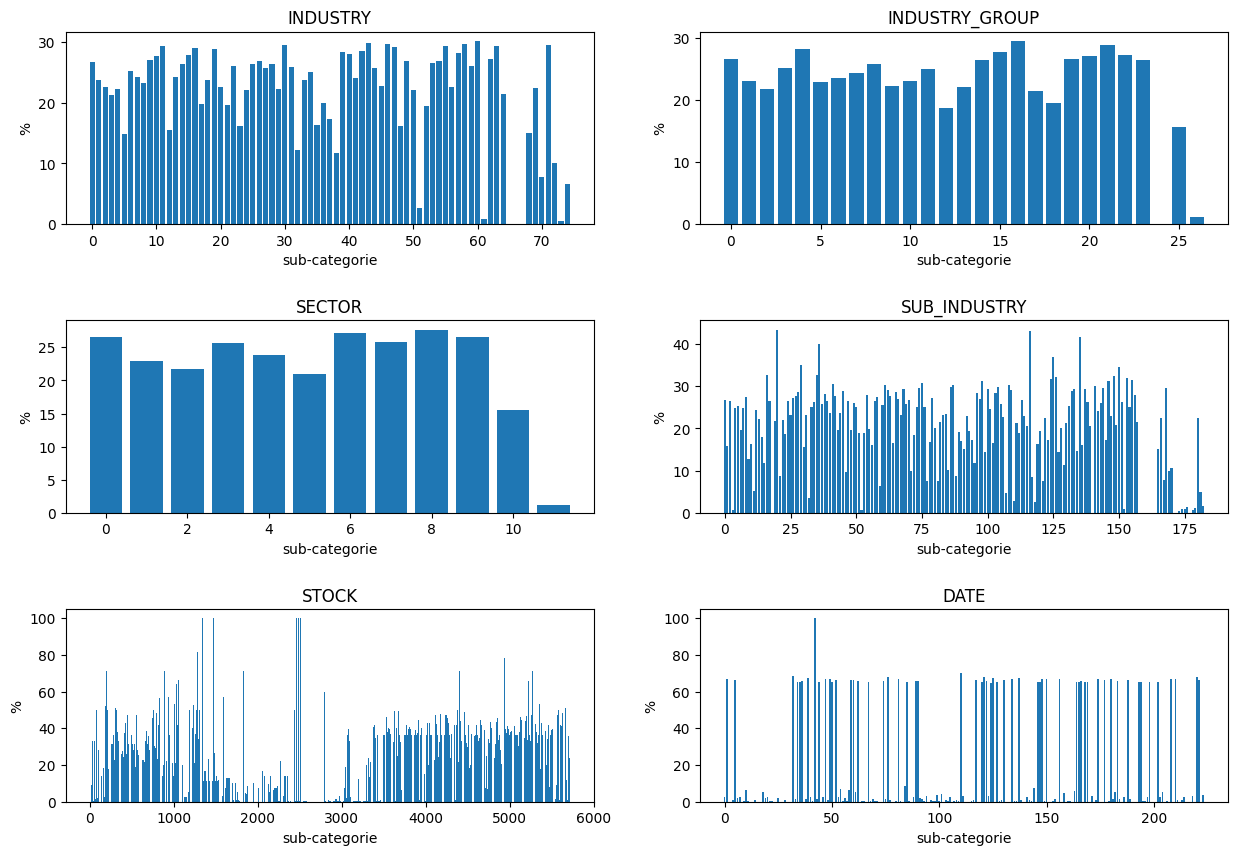

In [9]:
plt.figure(figsize=(15,10))
plt.subplots_adjust(hspace=0.5)
for i,categorie in enumerate(['INDUSTRY', 'INDUSTRY_GROUP', 'SECTOR', 'SUB_INDUSTRY', 'STOCK', 'DATE']): 
    plt.subplot(3,2,i+1)
    plt.title(categorie)
    X_absciss = cleaning_train[categorie].sort_values().unique()

    unique_Y_values = cleaning_train[categorie].sort_values().unique()
    Y_absciss = [(cleaning_train[cleaning_train[categorie]==sub_categorie].isna().sum(axis=1)>0).sum()/len(cleaning_train[cleaning_train[categorie]==sub_categorie])*100 for sub_categorie in unique_Y_values]
    
    plt.bar(X_absciss,Y_absciss)
    plt.xlabel('sub-categorie')
    plt.ylabel('%')
plt.show()

The plots display the percentage of NaN values per subcategory. We observe a relatively even distribution of missing values for the categorical variable SECTOR, whereas the amount of missing data in other categorical features appears less uniform.

It may be useful to investigate whether some rows mainly consist of missing values in the descriptive variables (RET and VOLUME). If that is the case, those observations can reasonably be removed, as they do not contribute meaningful information to the model.

We will first **remove rows with heavy missingness**, then **impute minor gaps** with consistent values.

#### Let's remove the rows where half or more of their features `RET_` and `VOL_` are NaN

In [10]:
to_drop = cleaning_train[cleaning_train[features].isna().sum(axis=1) >= len(features)*0.5][features].index
nb_drop = len(to_drop)
nb_rows = len(cleaning_train)
print(
    f"Number of rows before removing: {nb_rows}\n"
    f"Number of rows removed: {nb_drop}\n"
    f"Overall ratio (% of rows removed): {nb_drop / nb_rows * 100:.4f}%"
)

cleaning_train.drop(index = to_drop, axis=0, inplace = True)

Number of rows before removing: 418595
Number of rows removed: 12767
Overall ratio (% of rows removed): 3.0500%


About 3% of the rows were less than half complete, which is a small proportion but still an important aspect to take into account during data cleaning.

In [11]:
cleaning_train.isna().sum(axis = 0)/len(cleaning_train)*100

DATE               0.000000
STOCK              0.000000
INDUSTRY           0.000000
INDUSTRY_GROUP     0.000000
SECTOR             0.000000
SUB_INDUSTRY       0.000000
RET_1              0.003450
VOLUME_1          12.925180
RET_2              0.005914
VOLUME_2          13.247731
RET_3              0.004435
VOLUME_3          13.598865
RET_4              0.002711
VOLUME_4          14.372099
RET_5              0.002711
VOLUME_5          15.279626
RET_6              0.004189
VOLUME_6          15.282336
RET_7              0.003203
VOLUME_7          15.068945
RET_8              0.002218
VOLUME_8          15.078309
RET_9              0.003203
VOLUME_9          14.928738
RET_10             0.002957
VOLUME_10         14.930463
RET_11             0.001478
VOLUME_11         14.601999
RET_12             0.034744
VOLUME_12         12.263323
RET_13             0.048050
VOLUME_13         11.395222
RET_14             0.230640
VOLUME_14         11.867836
RET_15             0.256266
VOLUME_15         13

From now on the stat of missing values are lower, but let's keep digging that way by replacing the missing values

#### Before that let's have a look at the features distributions

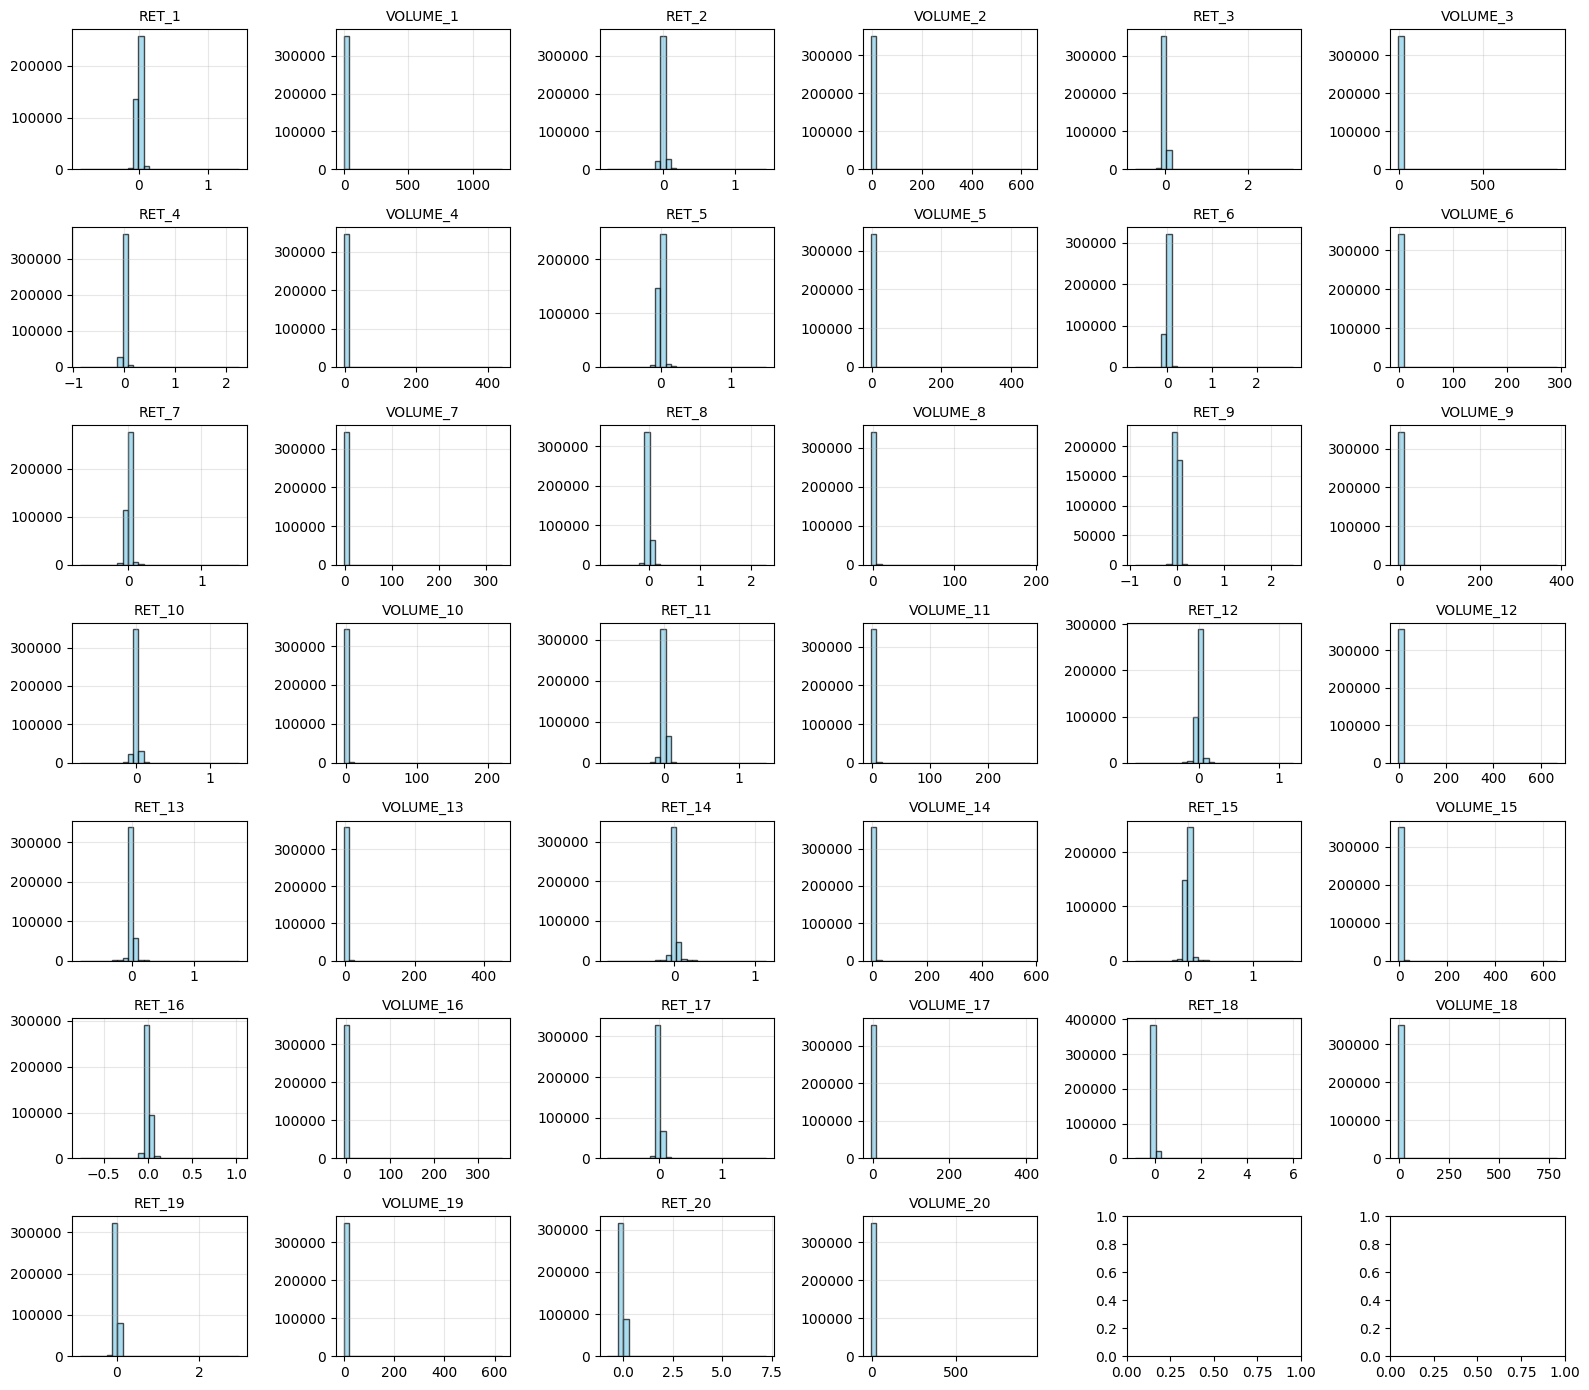

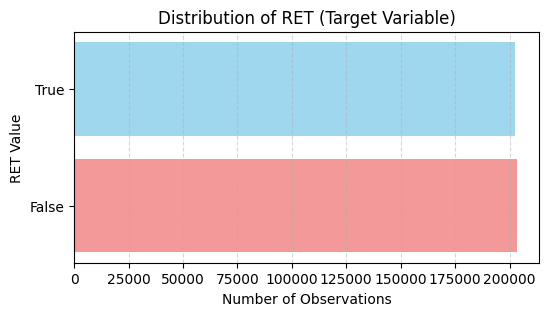

In [12]:
features = [col for col in cleaning_train.columns if col not in ["INDUSTRY", "INDUSTRY_GROUP", "SECTOR", "SUB_INDUSTRY", "STOCK", "DATE","RET"]]
n_cols = 6
n_rows = int(np.ceil(len(features) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 14))
axes = axes.flatten()

for i, feature in enumerate(features):
    cleaning_train[feature].hist(bins=30, ax=axes[i], alpha=0.7, color='skyblue', edgecolor='black')
    axes[i].set_title(feature, fontsize=10)
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

ret_counts = cleaning_train["RET"].value_counts()
plt.figure(figsize=(6, 3))
plt.barh(ret_counts.index.astype(str), ret_counts.values, color=["lightcoral", "skyblue"], alpha=0.8)
plt.title("Distribution of RET (Target Variable)")
plt.xlabel("Number of Observations")
plt.ylabel("RET Value")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.show()


The plots are not very meaningful since most values are centered around 0. This is consistent with the nature of the data: we are dealing with relative volumes and residual returns, which are either normalized or expressed relative to market behavior after removing overall market effects. Nevertheless, it is interesting to note that the RET values are fairly well balanced.

In [13]:
volume = pd.DataFrame(columns=['day', 'ret_mean', 'ret_median', 'ret_std', 'vol_mean', 'vol_median', 'vol_std'])
for day in range(1,11):
    volume.loc[day] =[day, cleaning_train[f'RET_{day}'].mean(), cleaning_train[f'RET_{day}'].median(), cleaning_train[f'RET_{day}'].std(), 
                      cleaning_train[f'VOLUME_{day}'].mean(), cleaning_train[f'VOLUME_{day}'].median(), cleaning_train[f'VOLUME_{day}'].std()]
volume

,day,ret_mean,ret_median,ret_std,vol_mean,vol_median,vol_std
1,1.0,0.001428,0.000691,0.031144,-0.071951,-0.282598,3.029095
2,2.0,0.001065,0.000518,0.030788,-0.075310,-0.278445,2.635940
3,3.0,0.002127,0.000953,0.031118,-0.097339,-0.278301,2.491170
4,4.0,-0.000793,-0.000595,0.030868,-0.089270,-0.275468,1.729502
5,5.0,0.000335,-0.000207,0.031644,-0.092331,-0.281258,1.848408
6,6.0,-0.000343,0.000000,0.031083,-0.100523,-0.288132,1.689204
7,7.0,0.000363,0.000168,0.030751,-0.084742,-0.284767,1.839759
8,8.0,0.000148,-0.000137,0.031326,-0.087015,-0.289754,1.595849
9,9.0,-0.000679,-0.000211,0.032676,-0.090916,-0.298195,1.857260
10,10.0,0.000115,0.000000,0.031323,-0.092331,-0.295769,1.652158


#### Missing Value Imputation Choice for `VOL_`

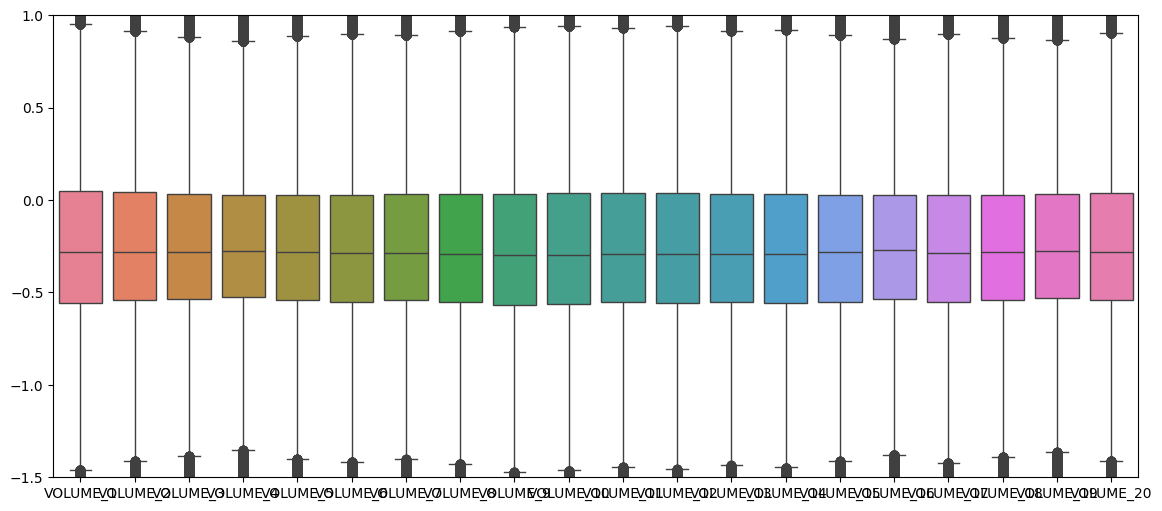

In [15]:
plt.figure(figsize=(14, 6))  # width = 20, height = 6
sns.boxplot(cleaning_train[[f'VOLUME_{day}' for day in range(1,21)]])
plt.ylim((-1.5,1))
plt.show()

##### Justification for Missing-Value Imputation (Volumes)

**A quick reminder — what is skewness?**  
Skewness describes the *asymmetry* of a distribution:  
- **Symmetric**: left and right tails are similar; mean ≈ median.  
- **Left-skewed (negative skew)**: longer/larger tail on the left; **mean < median**.  
- **Right-skewed (positive skew)**: longer/larger tail on the right; **mean > median**.  

**What we observe for `VOLUME_1`–`VOLUME_10`:**  
- The **median is around −0.25** across all volume features (i.e., slightly shifted left, not centered at 0, and showing **no extreme skew**).  
- Outliers exist but are not dominant, and we will handle them later.  

**Why we impute with the median:**  
- The **median is robust** to outliers, unlike the mean, which is affected by them.  
- Therefore, based on our boxplots, imputing with the **mean** would be too optimistic and could distort the true distribution.



In [16]:
per_feature_median_volume = cleaning_train[vol_features].median()
print(per_feature_median_volume)
cleaning_train[vol_features] = cleaning_train[vol_features].fillna(per_feature_median_volume)

VOLUME_1    -0.282598
VOLUME_2    -0.278445
VOLUME_3    -0.278301
VOLUME_4    -0.275468
VOLUME_5    -0.281258
VOLUME_6    -0.288132
VOLUME_7    -0.284767
VOLUME_8    -0.289754
VOLUME_9    -0.298195
VOLUME_10   -0.295769
VOLUME_11   -0.291194
VOLUME_12   -0.291345
VOLUME_13   -0.292227
VOLUME_14   -0.293027
VOLUME_15   -0.282044
VOLUME_16   -0.272271
VOLUME_17   -0.285476
VOLUME_18   -0.281744
VOLUME_19   -0.277668
VOLUME_20   -0.283404
dtype: float64


#### Missing Value Imputation Choice for `RET_`

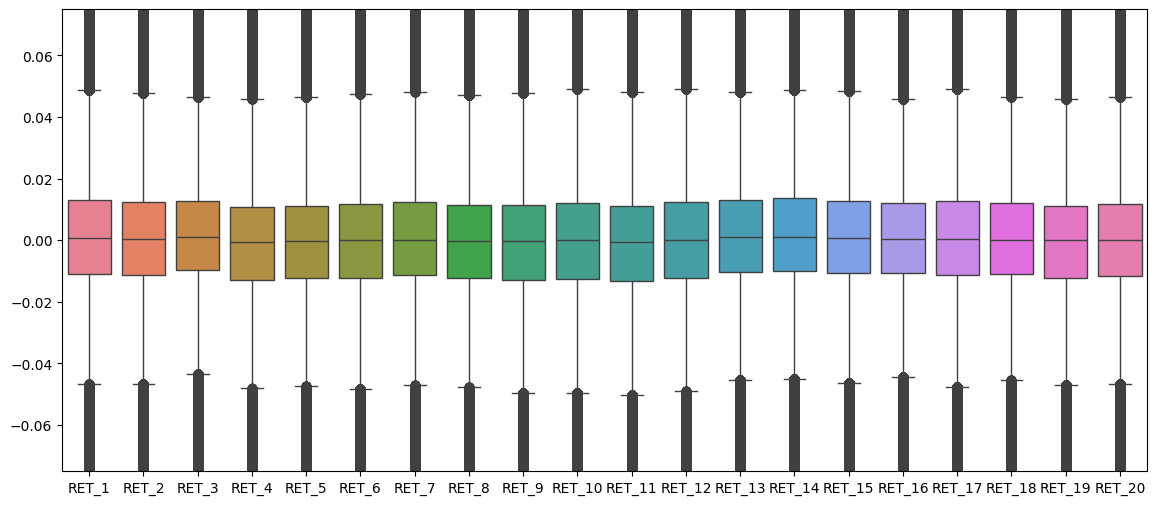

In [17]:
plt.figure(figsize=(14, 6))  # width = 20, height = 6
sns.boxplot(cleaning_train[[f'RET_{day}' for day in range(1,21)]])
plt.ylim((-0.075,0.075))
plt.show()

For the `RET_` features, the **median is close to 0**, indicating a symmetric distribution around the center.  
Although imputing missing values with the **mean** could be appropriate in this case, we will use the **median** instead to remain consistent with a **robust imputation strategy** less sensitive to potential outliers.


In [18]:
per_feature_median_return  = cleaning_train[ret_features].median()
print(per_feature_median_return)
cleaning_train[ret_features] = cleaning_train[ret_features].fillna(per_feature_median_return)

RET_1     0.000691
RET_2     0.000518
RET_3     0.000953
RET_4    -0.000595
RET_5    -0.000207
RET_6     0.000000
RET_7     0.000168
RET_8    -0.000137
RET_9    -0.000211
RET_10    0.000000
RET_11   -0.000579
RET_12    0.000000
RET_13    0.001094
RET_14    0.001144
RET_15    0.000814
RET_16    0.000509
RET_17    0.000413
RET_18    0.000000
RET_19    0.000000
RET_20    0.000000
dtype: float64


#### Just checking that all the features are well imputated

In [19]:
cleaning_train.isna().sum(axis = 0)/len(cleaning_train)*100

DATE              0.0
STOCK             0.0
INDUSTRY          0.0
INDUSTRY_GROUP    0.0
SECTOR            0.0
SUB_INDUSTRY      0.0
RET_1             0.0
VOLUME_1          0.0
RET_2             0.0
VOLUME_2          0.0
RET_3             0.0
VOLUME_3          0.0
RET_4             0.0
VOLUME_4          0.0
RET_5             0.0
VOLUME_5          0.0
RET_6             0.0
VOLUME_6          0.0
RET_7             0.0
VOLUME_7          0.0
RET_8             0.0
VOLUME_8          0.0
RET_9             0.0
VOLUME_9          0.0
RET_10            0.0
VOLUME_10         0.0
RET_11            0.0
VOLUME_11         0.0
RET_12            0.0
VOLUME_12         0.0
RET_13            0.0
VOLUME_13         0.0
RET_14            0.0
VOLUME_14         0.0
RET_15            0.0
VOLUME_15         0.0
RET_16            0.0
VOLUME_16         0.0
RET_17            0.0
VOLUME_17         0.0
RET_18            0.0
VOLUME_18         0.0
RET_19            0.0
VOLUME_19         0.0
RET_20            0.0
VOLUME_20 

Alright, the missing values have been successfully replaced using the median strategy.  
We can now move on to the **outlierss**, where we will different methods in order to remove them.


### 1-B) MISSING VALUES FOR TEST 

In [ ]:
test.isna().sum(axis = 0)/len(test)*100

DATE               0.000000
STOCK              0.000000
INDUSTRY           0.000000
INDUSTRY_GROUP     0.000000
SECTOR             0.000000
SUB_INDUSTRY       0.000000
RET_1              0.004032
VOLUME_1          13.702634
RET_2              0.008567
VOLUME_2          12.797525
RET_3              0.011087
VOLUME_3          13.793851
RET_4              0.016631
VOLUME_4          14.715087
RET_5              0.021166
VOLUME_5          15.670593
RET_6              0.022678
VOLUME_6          15.674120
RET_7              0.023182
VOLUME_7          15.677648
RET_8              0.022174
VOLUME_8          15.683191
RET_9              0.020158
VOLUME_9          15.687223
RET_10             0.030238
VOLUME_10         14.742301
RET_11             0.530668
VOLUME_11         14.254469
RET_12             0.083657
VOLUME_12         12.780390
RET_13             0.138085
VOLUME_13         12.843889
RET_14             0.837579
VOLUME_14         14.419767
RET_15             1.017492
VOLUME_15         14

We've identified missing values in the test dataset. To ensure consistent preprocessing and prevent **data leakage**, we'll impute these values using the same strategy applied to the training set.

Specifically, missing values will be replaced by the median of their respective columns, which was **pre-calculated** on the training data. This approach ensures the test set imputation introduces no information from the test set itself.

In [21]:
test[vol_features] = test[vol_features].fillna(per_feature_median_volume)

test[ret_features] = test[ret_features].fillna(per_feature_median_return)

In [ ]:
test.isna().sum(axis = 0)/len(test)*10

DATE              0.0
STOCK             0.0
INDUSTRY          0.0
INDUSTRY_GROUP    0.0
SECTOR            0.0
SUB_INDUSTRY      0.0
RET_1             0.0
VOLUME_1          0.0
RET_2             0.0
VOLUME_2          0.0
RET_3             0.0
VOLUME_3          0.0
RET_4             0.0
VOLUME_4          0.0
RET_5             0.0
VOLUME_5          0.0
RET_6             0.0
VOLUME_6          0.0
RET_7             0.0
VOLUME_7          0.0
RET_8             0.0
VOLUME_8          0.0
RET_9             0.0
VOLUME_9          0.0
RET_10            0.0
VOLUME_10         0.0
RET_11            0.0
VOLUME_11         0.0
RET_12            0.0
VOLUME_12         0.0
RET_13            0.0
VOLUME_13         0.0
RET_14            0.0
VOLUME_14         0.0
RET_15            0.0
VOLUME_15         0.0
RET_16            0.0
VOLUME_16         0.0
RET_17            0.0
VOLUME_17         0.0
RET_18            0.0
VOLUME_18         0.0
RET_19            0.0
VOLUME_19         0.0
RET_20            0.0
VOLUME_20 

## II.2) Outliers handling

### IQR Method

The **Interquartile Range (IQR) rule** was applied to detect and remove outliers in the `RET_` features.  

$$
\text{Lower bound} = Q1 - 1.5 \times IQR
$$
$$
\text{Upper bound} = Q3 + 1.5 \times IQR
$$

$$ IQR = Q3 - Q1 $$

This method identifies values lying beyond **1.5 × IQR** from the first (Q1) and third (Q3) quartiles.  

Nb lignes supprimées IQR : 209841, equivalently to 51.7% of total dataset


(-0.05, 0.05)

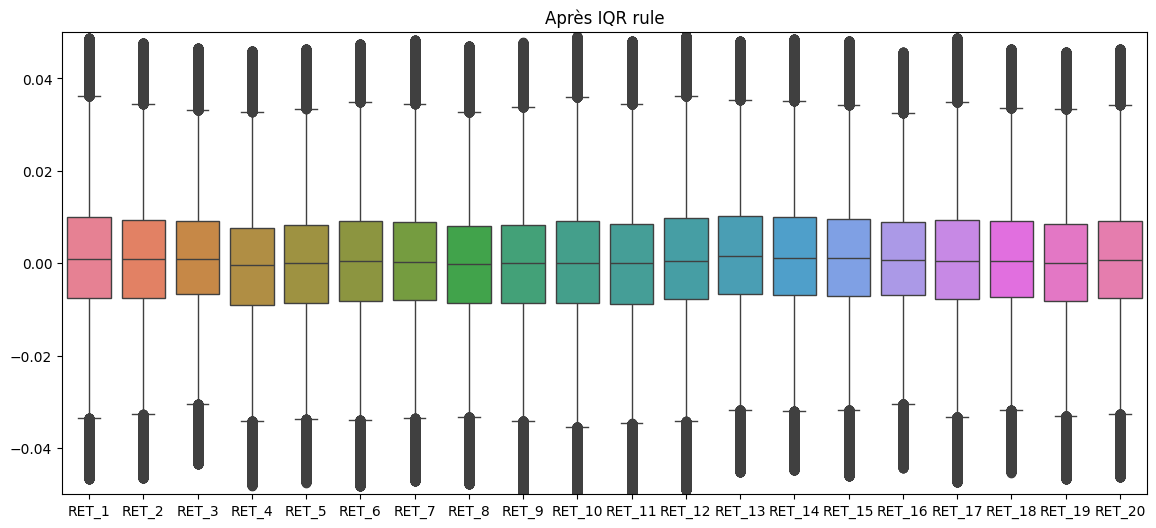

In [ ]:
features = ret_features + vol_features
X = cleaning_train[ret_features]

Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)
IQR = Q3 - Q1
mask_iqr = ~((X < (Q1 - 1.5 * IQR)) | (X > (Q3 + 1.5 * IQR))).any(axis=1)
cleaning_train_iqr = cleaning_train[mask_iqr]

nb_tot = len(cleaning_train)
nb_removed = nb_tot - len(cleaning_train_iqr)
print(f"Nb lignes supprimées IQR : {nb_removed}, equivalently to {(nb_removed/nb_tot)*100:.1f}% of total dataset")
plt.figure(figsize=(14, 6))
sns.boxplot(cleaning_train_iqr[ret_features])
plt.title("After  IQR rule")
plt.ylim((-0.05, 0.05))

After applying this rule, the overall distribution of returns **remains consistent, with medians close to 0** and fewer extreme values.  
This confirms that the 51.7% removed observations were genuine **outliers**, allowing for a cleaner and more stable dataset while preserving the main statistical structure.  
Nevertheless, it is important to emphasize that the removal of over half the dataset highlights **the significant level of noise** in the initial data.

### IsolationForest Method

The **Isolation Forest** algorithm is a model-based method for outlier detection.  
Unlike the IQR rule, which relies on fixed statistical thresholds, Isolation Forest identifies anomalies by **isolating observations** that differ significantly from the majority.  
It works by randomly selecting features and split values to construct multiple decision trees, and the **number of splits required to isolate a point** determines how “anomalous” it is:  
- **Normal points** require many splits (they are deeply nested).  
- **Outliers** are isolated quickly (few splits needed).  

In this analysis, we applied Isolation Forest with a contamination rate of **5%**, meaning the model assumes roughly 5% of the data could be anomalous.  

Nb lignes supprimées IQR : 20292, equivalently to 5.0% of total dataset


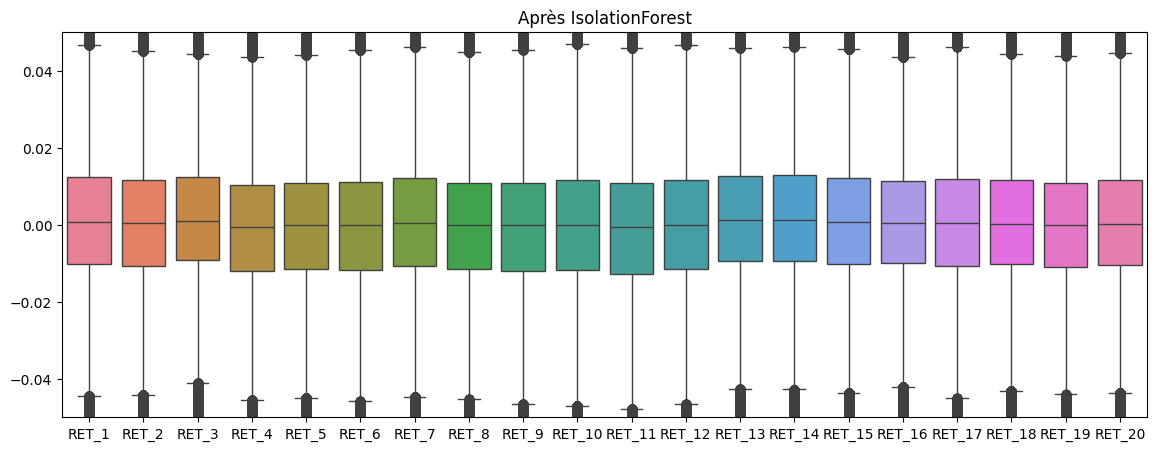

In [ ]:
iso = IsolationForest(contamination=0.05, random_state=42)
y_pred_iso = iso.fit_predict(X)
cleaning_train_iso = cleaning_train[y_pred_iso == 1]  # 1 = normal, -1 = outlier

nb_tot = len(cleaning_train)
nb_removed = nb_tot - len(cleaning_train_iso)
print(f"Nb lignes supprimées IQR : {nb_removed}, equivalently to {(nb_removed/nb_tot)*100:.1f}% of total dataset")

plt.figure(figsize=(14, 5))
sns.boxplot(cleaning_train_iso[ret_features])
plt.title("After IsolationForest")
plt.ylim((-0.05, 0.05))

plt.show()

After applying the method, the **overall structure of the `RET_` features remains stable**, with medians still around 0 and distributions symmetric.  
This indicates that the algorithm primarily removed **a small proportion of extreme or inconsistent observations**, improving dataset quality without distorting its core statistical behavior.  
Overall, the data is now cleaner and more consistent for subsequent modeling steps.


## II.3) Imbalanced Data handling

In [26]:
print(cleaning_train['RET'].value_counts(normalize=True)*100)
print(cleaning_train_iso['RET'].value_counts(normalize=True)*100)
print(cleaning_train_iqr['RET'].value_counts(normalize=True)*100)

RET
False    50.131829
True     49.868171
Name: proportion, dtype: float64
RET
False    50.040723
True     49.959277
Name: proportion, dtype: float64
RET
True     50.885518
False    49.114482
Name: proportion, dtype: float64


Considering the large size of the dataset (over 400k samples), the observed proportions suggest that the data is **statistically balanced**.  
Consequently, we will proceed **without implementing additional data augmentation or balancing strategies.**

# III) Feature Engineering

In [27]:
new_features = []
frames = [cleaning_train_iso.copy(), cleaning_train_iqr.copy(), test.copy()]

## III.1) Target Features (Conditional)

### `RET_{shift}_SECTOR_DATE_stat`

In [ ]:
shifts = [1,2,3,4] 
statistics = ['mean']
gb_features_list = [['SECTOR', 'DATE']]
target_features = ['RET']
for target_feature in target_features:
    for gb_features in gb_features_list:
        tmp_name = '_'.join(gb_features)
        for shift in shifts:
            for stat in statistics:
                name = f'{target_feature}_{shift}_{tmp_name}_{stat}'
                feat = f'{target_feature}_{shift}'
                new_features.append(name)
                for data in frames:
                    data[name] = data.groupby(gb_features)[feat].transform(stat)
                    
print(len(new_features))

4


This block creates new features like `RET_{shift}_SECTOR_DATE_mean` for each return lag (1–4).

For every (`SECTOR`, `DATE`) group, it computes the mean of the shifted return and assigns it to all rows in that group using groupby().transform('mean').\
It’s applied to both train and test to capture average sector-level performance on each date.

### `RET_STOCK_WEEK_{week}_stat`

In [29]:
weeks = 2
statistics = ['mean', 'std']
gb_features_list = [['STOCK', 'DATE']]

target_features = ['RET', 'VOLUME'] 
for target_feature in target_features:
    for gb_features in gb_features_list:
        tmp_name = '_'.join(gb_features)
        for stat in statistics:
            for week in range(weeks):
                name = f'{stat}_{target_feature}_STOCK_WEEK_{week+1}'
                new_features.append(name)
                for data in frames:
                    if stat == 'mean':
                        if target_feature == 'VOLUME':
                            data[name] = data[[f'{target_feature}_{week*5 + day}' for day in range(1,6)]].mean(axis=1).abs()
                        else:
                            data[name] = data[[f'{target_feature}_{week*5 + day}' for day in range(1,6)]].mean(axis=1)
                    elif stat == 'std':
                        data[name] = data[[f'{target_feature}_{week*5 + day}' for day in range(1,6)]].std(axis=1)
                    elif stat == 'min':
                        data[name] = data[[f'{target_feature}_{week*5 + day}' for day in range(1,6)]].min(axis=1)
                    elif stat == 'max':
                        data[name] = data[[f'{target_feature}_{week*5 + day}' for day in range(1,6)]].max(axis=1)
                    elif stat == 'median':
                        data[name] = data[[f'{target_feature}_{week*5 + day}' for day in range(1,6)]].median(axis=1)
                        
print(len(new_features))

12


**Under the assumption, that 1 week = 5 days**

This block creates new features like `RET_STOCK_WEEK_{week}_mean` and `VOLUME_STOCK_WEEK_{week}_std` for four consecutive weeks.\
For each week, it computes the mean or standard deviation of the previous five daily lags (5 days per week) for `RET_` and `VOLUME_`.\
It’s applied to both train and test to capture short-term stock-level trends and volatility patterns.

### Stock's volume compared to its sector

In [30]:
shifts = [1,2] 
statistics = ['sum']
gb_features_list = [['SECTOR', 'DATE']]
target_features = ['mean_VOLUME_STOCK_WEEK']
for target_feature in target_features:
    for gb_features in gb_features_list:
        tmp_name = '_'.join(gb_features)
        for shift in shifts:
            for stat in statistics:
                name = f'{target_feature}_{shift}_/total_VOLUME_of_SECTOR_DATE'
                feat = f'{target_feature}_{shift}'
                new_features.append(name)
                for data in frames:
                    data[name] = data[feat]/data.groupby(gb_features)[feat].transform('sum')
                    
print(len(new_features))

14


Next, we implement the relative measure of the stock's volume compared to its sector. It is similar to normalization.\
This block creates features like `VOLUME_STOCK_WEEK_{shift}_mean/total_VOLUME_of_SECTOR_DATE` for shifts 1–4.\
For each (`SECTOR`, `DATE`) group, it divides each stock’s shifted weekly volume by the group’s total volume using groupby().transform('sum').\
It’s applied to both train and test to capture each stock’s relative share of sector trading activity.

### Return's volume compared to its sector

In [ ]:
shifts = [1,2] 
statistics = ['sum'] 
gb_features_list = [['SECTOR', 'DATE']]
target_features = ['mean_RET_STOCK_WEEK']
for target_feature in target_features:
    for gb_features in gb_features_list:
        tmp_name = '_'.join(gb_features)
        for shift in shifts:
            for stat in statistics:
                name = f'{target_feature}_{shift}_/total_RET_of_SECTOR_DATE'
                feat = f'{target_feature}_{shift}'
                new_features.append(name)
                for data in frames:
                    data[name] = data[feat]/data.groupby(gb_features)[feat].transform('sum')
                    
print(len(new_features))

16


### `RET_10_day_momentum / VOLUME_10_day_momentum`

In [32]:
weeks = [2]
targets = ['RET', 'VOLUME']

for target in targets:
    for week in weeks: 
        window_size = 5*week
        name = f'{target}_{window_size}_day_momentum'
        new_features.append(name)
        for data in frames:
            _data = data.copy()
            rolling_mean_target = _data.groupby(by=['SECTOR', 'DATE'])[[f'{target}_{day}' for day in range(2, window_size+1)]].mean()
            target_1_mean = _data.groupby(by=['SECTOR', 'DATE'])[[f'{target}_1']].mean()
            target_1_mean_aligned, rolling_mean_target_aligned = target_1_mean.align(rolling_mean_target, axis=0, level='SECTOR')
            target_momentum = target_1_mean_aligned.sub(rolling_mean_target_aligned.mean(axis=1), axis=0)
            target_momentum.rename(columns={f'{target}_1': name},inplace=True)
            placeholder = _data.join(target_momentum, on=['SECTOR', 'DATE'], how='left')
            data[name] = placeholder[name]
            
print(len(new_features))

18


We add a more dynamic feature, called residual return momentum. We do so by calculating the average return over day D-1,...,D-10 and subtract the return of day D to obtain an idea where our stock might go. The residual return momentum reflects recent performance trends.\
This block creates features like `RET_10_day_momentum` and `VOLUME_10_day_momentum`.\
For each (`SECTOR`, `DATE`) group, it compares the most recent day’s average (target_1) to the mean of the previous 10 days to measure short-term momentum.\
It’s applied to both train and test to capture recent performance shifts or activity surges within each sector.

### `10_day_mean_RET_vola / 10_day_mean_VOLUME_vola`

In [33]:
weeks = [2]
targets = ['RET', 'VOLUME']

for week in weeks: 
    window_size = 5*week
    for target in targets: 
        name = f'{window_size}_day_mean_{target}_vola'
        new_features.append(name)
        for data in frames:
            rolling_std_target = data.groupby(by=['SECTOR', 'DATE'])[[f'{target}_{day}' for day in range(1,window_size+1)]].mean().std(axis=1).to_frame(name)
            placeholder = data.join(rolling_std_target, on=['SECTOR', 'DATE'], how='left')
            data[name] = placeholder[name]
            
print(len(new_features))

20


Compute the standard deviation of the averages to measure volatility (conditioned on sector).\
This block computes the average volatility of `RET_` and `VOLUME_` over the past 10 days within each (`SECTOR`, `DATE`) group.\
It calculates the standard deviation of the 10-day rolling mean to capture short-term fluctuations.\
Applied to all datasets, it reflects recent instability or variability in returns and trading volumes.

### `RSI_SECTOR_DATE_20`

In [34]:
targets = ["RET"]
window_size = 10
name = f"RSI_SECTOR_DATE_{window_size}"
new_features.append(name)

for target in targets:
    for data in frames:
        _data = data.copy()
        avg_gain_sector_day = _data.groupby(by=['SECTOR', 'DATE'])[[f'{"RET"}_{day}' for day in range(1, window_size+1)]].mean().agg(lambda x: x[x>0].mean(), axis=1)
        avg_loss_sector_day = _data.groupby(by=['SECTOR', 'DATE'])[[f'{"RET"}_{day}' for day in range(1, window_size+1)]].mean().agg(lambda x: x[x<0].mean(), axis=1).abs()
        rs_sector_day = avg_gain_sector_day/avg_loss_sector_day
        rsi_sector_date = 100 - 100/(1+rs_sector_day)
        placeholder = _data.join(rsi_sector_date.to_frame(name), on=['SECTOR', 'DATE'], how='left')
        data[name] = placeholder[name]
        
print(len(new_features))

21


We are now going to add the relative strength index per sector. The RSI measures the speed and change of price movements.
This block computes a 20-day sector-level Relative Strength Index (RSI) based on RET.
For each (`SECTOR`, `DATE`) group, it calculates the average gains and losses over the past 20 days, derives the relative strength ratio, and converts it into an RSI value.
Applied to all datasets, it captures short-term momentum intensity and potential overbought or oversold conditions within each sector.

### `Sum_ADL`

In [35]:
window_size = 5
name = 'Sum_ADL'
new_features.append(name)

for data in frames:
    _data = data.copy()
    sum_adl = ((_data.groupby(by=["SECTOR", "DATE"])[[f'RET_{day}' for day in range(1, window_size+1)]]).apply(lambda x: (x>0).sum()) - (_data.groupby(by=["SECTOR", "DATE"])[[f'RET_{day}' for day in range(1, window_size+1)]]).apply(lambda x: (x<0).sum())).sum(axis=1)
    placeholder = _data.join(sum_adl.to_frame(name), on=['SECTOR', 'DATE'], how='left')
    data[name] = placeholder[name]
    
print(len(new_features))

22


$ \text{ADL}_{\text{sum}} = \sum_i \text{Net\_Advances}_i $ — *(signals overall market trends)*

where
$ \text{Net\_Advances}_i = \text{Advances}_i − \text{Declines}_i $

$ \text{Advances}_i $ → number of assets for each (`SECTOR`, `DATE`) group with positive returns on day $i$\
$ \text{Declines}_i $ → number of assets for each (`SECTOR`, `DATE`) group with negative returns on day $i$

This block computes a 5-day Advance–Decline Line (ADL) indicator for each (`SECTOR`, `DATE`) group.\
It counts the number of positive (`RET_` > 0) and negative (`RET_` < 0) returns over the past 5 days and takes their difference.\
Applied to all datasets, it measures short-term market breadth within each sector, indicating whether gains or losses dominate.

In [36]:
print(new_features)

['RET_1_SECTOR_DATE_mean', 'RET_2_SECTOR_DATE_mean', 'RET_3_SECTOR_DATE_mean', 'RET_4_SECTOR_DATE_mean', 'mean_RET_STOCK_WEEK_1', 'mean_RET_STOCK_WEEK_2', 'std_RET_STOCK_WEEK_1', 'std_RET_STOCK_WEEK_2', 'mean_VOLUME_STOCK_WEEK_1', 'mean_VOLUME_STOCK_WEEK_2', 'std_VOLUME_STOCK_WEEK_1', 'std_VOLUME_STOCK_WEEK_2', 'mean_VOLUME_STOCK_WEEK_1_/total_VOLUME_of_SECTOR_DATE', 'mean_VOLUME_STOCK_WEEK_2_/total_VOLUME_of_SECTOR_DATE', 'mean_RET_STOCK_WEEK_1_/total_RET_of_SECTOR_DATE', 'mean_RET_STOCK_WEEK_2_/total_RET_of_SECTOR_DATE', 'RET_10_day_momentum', 'VOLUME_10_day_momentum', '10_day_mean_RET_vola', '10_day_mean_VOLUME_vola', 'RSI_SECTOR_DATE_10', 'Sum_ADL']


## III.2) Linear and Interaction Features

### Basic Features

This cell creates foundational features that capture raw market behavior patterns:

- **Absolute returns** measure price movement magnitude regardless of direction
- **Realized volatility** (20-day) quantifies market uncertainty and risk
- **Volume ratios** detect unusual trading activity
- **Return skewness** identifies asymmetric price distributions

These features are essential because machine learning models need numerical representations of market dynamics. Absolute returns matter because extreme price moves tend to revert to mean values. Volume ratios signal informed traders entering positions. Skewness identifies distributions with heavy tails predicting larger future moves.

We create  
`abs_ret_1` = |RET_1|,  
`abs_ret_mean_5d` = mean(|RET_1|,...,|RET_5|)  
`realized_vol_20d` = std(RET_1,...,RET_20) which measures return dispersion over 20 days,  
`vol_ratio` = mean(VOLUME_1,...,VOLUME_5) / mean(VOLUME_6,...,VOLUME_20) which compares recent vs historical volume, and  
`ret_skewness` = skewness(RET_1,...,RET_20) which measures distribution asymmetry indicating tail risk.  

The reason we compute these is that financial returns aren't normally distributed and extreme moves (high skewness) often mean-revert fast. Volume ratio identifies when traders suddenly increase or decrease activity which predicts big price moves.

In [37]:
for data in frames :
    data['abs_ret_1'] = data['RET_1'].abs()
    data['abs_ret_mean_5d'] = data[['RET_1', 'RET_2', 'RET_3', 'RET_4', 'RET_5']].abs().mean(axis=1)
    data['realized_vol_20d'] = data[[f'RET_{i}' for i in range(1, 21)]].std(axis=1)
    data['vol_ratio'] = data['VOLUME_1'] / data[[f'VOLUME_{i}' for i in range(2, 6)]].mean(axis=1)

new_features += ["abs_ret_1"] + ["abs_ret_mean_5d"] + ["realized_vol_20d"] + ["vol_ratio"]

print(len(new_features))

26


### `rolling_vol_10d & rolling_vol_20d`
Specifies rolling volatility over 10 & 20 days.

**rolling_vol_10d**: $\text{std}(RET_1, ..., RET_{10})$

**rolling_vol_20d**: $\text{std}(RET_1, ..., RET_{20})$

In [38]:
for data in frames :
    ret_cols_10 = [f'RET_{i}' for i in range(1, 11)]
    ret_cols_20 = [f'RET_{i}' for i in range(1, 21)]
    data['rolling_vol_10d'] = data[ret_cols_10].std(axis=1)
    data['rolling_vol_20d'] = data[ret_cols_20].std(axis=1)

new_features += ['rolling_vol_10d'] + ['rolling_vol_20d']  
print(len(new_features))

28


### `parkinson_vol`
Specifies Parkinson volatility based on high-low price range.

**parkinson_vol** uses $\sigma_P = \frac{\ln(\max(RET) / \min(RET))}{2 \sqrt{\ln(2)}}$ to capture volatility via range only.

In [39]:

def parkinson_vol_vectorized(df):
    ret_max = df.max(axis=1)
    ret_min = df.min(axis=1)

    ratio = np.abs(ret_max) / np.abs(ret_min + 1e-8)
    range_val = np.log(ratio)
    same_sign = (ret_max <= 0) | (ret_min >= 0)
    std_vals = df.std(axis=1)
    parkinson_vals = range_val / (2 * np.sqrt(np.log(2)))
    parkinson_vals[same_sign] = std_vals[same_sign]

    return parkinson_vals

for data in frames:
    data['parkinson_vol'] = parkinson_vol_vectorized(data[ret_cols_20])

new_features.append('parkinson_vol')
print(len(new_features))


c:\Applications\Anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Applications\Anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


29


### `atr_proxy`
Specifies the Average True Range proxy, measuring the mean absolute change between consecutive returns.

**atr_proxy**: mean of $|RET_i - RET_{i-1}|$

In [40]:
def atr_proxy_vectorized(df):
    arr = df.to_numpy(float)                                  
    diff_abs = np.abs(np.diff(arr, axis=1))                   
    abs_vals = np.abs(arr[:, :-1])                            
    tr = np.maximum(diff_abs, abs_vals)                       
    atr_vals = np.nanmean(tr, axis=1)                         
    return np.nan_to_num(atr_vals, nan=0.0)                    

for data in frames:
    data['atr_proxy'] = atr_proxy_vectorized(data[ret_cols_10])  

new_features.append("atr_proxy")
print(len(new_features))

30


### `range_normalized`
Specifies the normalized daily range, expressing the spread between the maximum and minimum return relative to the opening or reference return.

**range_normalized**: $\frac{\max(RET) - \min(RET)}{|RET_1|}$

In [41]:
def normalized_range_vectorized(df, last_col='RET_1'):
    ret_max = df.max(axis=1)                                  
    ret_min = df.min(axis=1)                                  
    ret_range = ret_max - ret_min                             
    last_ret = df[last_col].abs()                             
    last_ret = last_ret.replace(0, np.nan)                    
    return (ret_range / last_ret).fillna(0)                   

for data in frames:
    data['range_normalized'] = normalized_range_vectorized(data[ret_cols_20]) 

new_features.append("range_normalized")
print(len(new_features))

31


### `rsi_14`
Specifies the Relative Strength Index (RSI) over 14 days, measuring the balance between gains and losses to indicate overbought or oversold market conditions.

**RSI**$_{14} = 100 - \left( \frac{100}{1 + RS} \right)$, where $RS = \frac{avg\_gain_{14}}{avg\_loss_{14}}$ measures overbought/oversold conditions indicating reversal probability.

In [42]:
ret_cols = [f'RET_{i}' for i in range(1, 21)]

def rsi_vectorized(df, period=14):
    arr = df.to_numpy(float)                                   # convert to NumPy array
    gains = np.maximum(arr, 0)                                 # positive returns
    losses = np.abs(np.minimum(arr, 0))                        # negative returns as positive
    avg_gain = np.apply_along_axis(lambda x: np.mean(x[-period:]), 1, gains)   # mean of last period gains
    avg_loss = np.apply_along_axis(lambda x: np.mean(x[-period:]), 1, losses)  # mean of last period losses
    rs = avg_gain / (avg_loss + 1e-8)                          # relative strength
    rsi = 100 - (100 / (1 + rs))                               # RSI formula
    return rsi

for data in frames:
    data['rsi_14'] = rsi_vectorized(data[ret_cols])           # apply vectorized RSI

new_features.append("rsi_14")
print(len(new_features))

32


### `macd`
Specifies the MACD signal, comparing short-term and long-term moving averages to identify momentum acceleration or deceleration.

**MACD:** = $mean(RET_{1:8}) - mean(RET_{1:20})$ detects momentum acceleration and deceleration.

In [43]:
def macd_vectorized(df, short_window=8):
    arr = df.to_numpy(float)                                   # convert to NumPy array
    short_len = min(short_window, arr.shape[1])                # handle case with < short_window columns
    sma_short = np.mean(arr[:, :short_len], axis=1)           # mean of first short_window returns
    sma_long = np.mean(arr, axis=1)                            # mean of all returns
    macd = sma_short - sma_long                                 # simplified MACD
    return macd

for data in frames:
    data['macd'] = macd_vectorized(data[ret_cols])            # apply vectorized MACD

new_features.append("macd")
print(len(new_features))

33


### `sma_5, sma_10, sma_20`
Specifies simple moving averages over 5, 10, and 20 days, providing core trend direction for multiple timeframes.


**SMA:** Simple moving averages for trend direction at multiple timeframes:
- $SMA_5 = mean(RET_{1:5})$
- $SMA_{10} = mean(RET_{1:10})$
- $SMA_{20} = mean(RET_{1:20})$

In [44]:
def sma_vectorized(df, period):
    arr = df.to_numpy(float)                                   # convert to NumPy array
    actual_period = min(period, arr.shape[1])                  # handle if fewer columns than period
    sma = np.mean(arr[:, :actual_period], axis=1)              # mean of first 'period' returns
    return sma

for data in frames:
    data['sma_5']  = sma_vectorized(data[ret_cols], 5)        # 5-day SMA
    data['sma_10'] = sma_vectorized(data[ret_cols], 10)       # 10-day SMA
    data['sma_20'] = sma_vectorized(data[ret_cols], 20)       # 20-day SMA

new_features += ["sma_5"] + ["sma_10"] + ["sma_20"]
print(len(new_features))

36


### `dist_to_sma5, dist_to_sma10, dist_to_sma20`
Specifies the distance from the current return to its corresponding moving average, quantifying deviation from the trend baseline.

**Distance to SMA:**$_K = RET_1 - SMA_K$, where $K \in \{5, 10, 20\}$ shows price deviation from trend baseline.

In [45]:
for data in frames:
    data['dist_to_sma5']  = data['RET_1'] - data['sma_5']      # distance to 5-day SMA
    data['dist_to_sma10'] = data['RET_1'] - data['sma_10']     # distance to 10-day SMA
    data['dist_to_sma20'] = data['RET_1'] - data['sma_20']     # distance to 20-day SMA

new_features += ["dist_to_sma5"] + ["dist_to_sma10"] + ["dist_to_sma20"]
print(len(new_features))

39


### `skewness_20d`, `kurtosis_20d`
Specifies rolling skewness (20 days), measuring if the distribution of returns is asymmetrical and prone to crashes (left skew) or rallies (right skew).


Specifies rolling kurtosis (20 days), quantifying how fat the tails are in returns—high kurtosis signals higher probability of extreme moves.

In [46]:
def skew_kurt_vectorized(df, cols):
    arr = df[cols].to_numpy(float)                    # convert to NumPy array

    col_mean = np.nanmean(arr, axis=0)
    inds = np.where(np.isnan(arr))
    arr[inds] = np.take(col_mean, inds[1])
    
    skew_vals = skew(arr, axis=1, bias=False)         # vectorized skew per row
    kurt_vals = kurtosis(arr, axis=1, bias=False)     # vectorized kurtosis per row
    return skew_vals, kurt_vals

for data in frames:
    data['skewness_20d'], data['kurtosis_20d'] = skew_kurt_vectorized(data, ret_cols)
    
new_features += ["skewness_20d"] + ["kurtosis_20d"]
print(len(new_features))

41


### `max_drawdown`
Specifies maximum drawdown, capturing the worst historical loss from peak, a key indicator of stress and downside risk.

In [47]:
def max_drawdown_vectorized(df):
    arr = df.to_numpy(float)                                  
    cum_returns = np.cumprod(1 + arr, axis=1) - 1             
    running_max = np.maximum.accumulate(cum_returns, axis=1)  
    drawdowns = (cum_returns - running_max) / (running_max + 1e-8) 
    return np.min(drawdowns, axis=1)                     

for data in frames:
    data['max_drawdown'] = max_drawdown_vectorized(data[ret_cols])

new_features.append("max_drawdown")
print(len(new_features))


42


### `days_since_peak`
Specifies the number of days since the cumulative return hit its highest point, revealing recovery momentum or persistent losses.



In [48]:
def days_since_peak_vectorized(df):
    arr = df.to_numpy(float)                                   
    cum_returns = np.cumprod(1 + arr, axis=1) - 1             
    peak_idx = np.argmax(cum_returns, axis=1)                
    days_since = arr.shape[1] - 1 - peak_idx                  
    return days_since

for data in frames:
    data['days_since_peak'] = days_since_peak_vectorized(data[ret_cols])  

new_features.append("days_since_peak")
print(len(new_features))

43


### `sharpe_ratio`
Specifies the risk-adjusted return (mean return divided by volatility), signaling shifts in the balance between reward and risk.

In [49]:
def sharpe_ratio_vectorized(df, rf_rate=0.0):
    arr = df.to_numpy(float)                                 
    mean_ret = np.nanmean(arr, axis=1)                        
    std_ret = np.nanstd(arr, axis=1)                          
    sharpe = (mean_ret - rf_rate) / (std_ret + 1e-8)          
    sharpe[std_ret == 0] = 0                                 
    return sharpe

for data in frames:
    data['sharpe_ratio'] = sharpe_ratio_vectorized(data[ret_cols], rf_rate=0.0)  

new_features.append("sharpe_ratio")
print(len(new_features))


44


### `zscore_ret_1`
Specifies the standardized return for yesterday, showing how exceptional the move was compared to local history (values $\pm3$ imply 99% reversal chance).

In [50]:
for data in frames:
    mean_ret = data[ret_cols].mean(axis=1)                     
    std_ret = data[ret_cols].std(axis=1) + 1e-8               
    data['zscore_ret_1'] = (data['RET_1'] - mean_ret) / std_ret 
    
new_features.append("zscore_ret_1")
print(len(new_features))

45


### `zscore_mean_ret`
Specifies the standardized average return, reflecting whether recent performance is unusually strong or weak relative to local volatility.

In [51]:
for data in frames:
    mean_ret = data[ret_cols].mean(axis=1)                   
    std_ret = data[ret_cols].std(axis=1) + 1e-8              
    data['zscore_mean_ret'] = mean_ret / std_ret             

new_features.append("zscore_mean_ret")
print(len(new_features))

46


#### Advanced Statistical Features Created

- **`skewness_20d`** : Distribution skewness over 20 days  
- **`kurtosis_20d`** : Distribution kurtosis (tail weight) over 20 days  
- **`max_drawdown`** : Maximum loss from peak cumulative return  
- **`days_since_peak`** : Days elapsed since the highest cumulative return  
- **`sharpe_ratio`** : Risk-adjusted return  
- **`zscore_ret_1`** : Standardized yesterday return  
- **`zscore_mean_ret`** : Standardized average return over 20 days


### `overnight_gap`
Specifies the overnight sentiment gap as $RET_1 - RET_2$, identifying shifts or imbalances at market open following news or non-trading hours.

`overnight_gap` = RET_1 - RET_2
Measures overnight sentiment shifts and opening imbalances, highlighting reactions to news or events outside trading hours.

In [52]:
diff_features = [
    ('overnight_gap', 'RET_1', 'RET_2'),
    ('gap_2_3', 'RET_2', 'RET_3'),  # example, can add more
]

for data in frames:
    for new_col, col1, col2 in diff_features:
        data[new_col] = data[col1].fillna(0) - data[col2].fillna(0) 

new_features += ["overnight_gap"] + ["gap_2_3"]
print(len(new_features))

48


### `intraday_range`
Specifies the intraday volatility intensity as $\max(RET) - \min(RET)$, measuring the largest within-day price swing.

`intraday_range`$ = \max(RET) - \min(RET)$
Quantifies the intensity of within-day volatility, revealing how extreme the intraday moves are.


In [53]:
for data in frames:
    data['intraday_range'] = data[ret_cols].max(axis=1) - data[ret_cols].min(axis=1) 

new_features.append("intraday_range")
print(len(new_features))

49


### `volume_normalized`, `volume_variation`
Specifies current trading volume normalized by its 20-day average, $VOLUME_1 / mean(VOLUME_{1:20})$; values above $1$ indicate abnormal trading activity.

Specifies volume consistency via $std(VOLUME) / mean(VOLUME)$, distinguishing stable from erratic volume patterns.

`volume_normalized`: = $\frac{VOLUME_1}{mean(VOLUME_{1:20})}$
Flags unusual trading activity; values above $1$ indicate accumulated or distributed trade flow.

`volume_variation`:$ = \frac{std(VOLUME)}{mean(VOLUME)}$
Measures volume consistency (low = stable, high = erratic trading).

In [ ]:
vol_cols = [f'VOLUME_{day}' for day in range(1,21)]  

for data in frames:
    vol_mean = data[vol_cols].mean(axis=1)                       
    data['volume_normalized'] = data['VOLUME_1'] / (vol_mean + 1e-8)   
    data['volume_variation'] = data[vol_cols].std(axis=1) / (vol_mean + 1e-8) 

new_features += ["volume_normalized"] + ["volume_variation"]
print(len(new_features))

51


### `autocorr_lag1`, `autocorr_lag2`, `autocorr_lag5`
Specifies the autocorrelation of returns at lag 1, reflecting how much yesterday's return predicts today—a positive value signals trend persistence.
Specifies the autocorrelation at lag 2, showing influence of returns two days prior on current moves.
Specifies weekly autocorrelation (lag 5), with a negative value indicating mean reversion acting on a weekly basis.


`autocorr_lag1`, autocorr_lag2, autocorr_lag5:

`autocorr_lag1`: Correlation of $RET_{1:19}$ with $RET_{2:20}$ (predictable daily pattern, positive = trend)

`autocorr_lag2`: Correlation of $RET_{1:18}$ with $RET_{3:20}$

`autocorr_lag5`: Correlation of $RET_{1:15}$ with $RET_{6:20}$ (negative = weekly mean reversion)

In [54]:
def autocorr_vectorized(df, ret_cols, lag):
    arr = df[ret_cols].to_numpy(float)                         
    n_rows, n_cols = arr.shape

    # Shifted arrays
    x = arr[:, :-lag]
    y = arr[:, lag:]
    
    # Compute mean per row
    mean_x = np.nanmean(x, axis=1, keepdims=True)
    mean_y = np.nanmean(y, axis=1, keepdims=True)
    
    # Covariance and std
    cov = np.nansum((x - mean_x) * (y - mean_y), axis=1)
    std_x = np.sqrt(np.nansum((x - mean_x)**2, axis=1))
    std_y = np.sqrt(np.nansum((y - mean_y)**2, axis=1))
    
    autocorr = cov / (std_x * std_y + 1e-8)                    
    autocorr[np.isnan(autocorr)] = 0                           
    
    return autocorr

lags = [1, 2, 5]
for data in frames:
    for lag in lags:
        col_name = f'autocorr_lag{lag}'
        if col_name not in new_features :
            new_features.append(col_name)
        data[col_name] = autocorr_vectorized(data, ret_cols, lag)

print(len(new_features))

52


#### Microstructure Features Created

- **`overnight_gap`** : Gap between days (RET_1 - RET_2)  
- **`intraday_range`** : Maximum range within the day (High - Low approximation)  
- **`volume_normalized`** : Current volume divided by average volume  
- **`volume_variation`** : Volume volatility (std / mean)  
- **`autocorr_lag1/2/5`** : Return autocorrelation at lags 1, 2, 5



# IV) Secondary Cleaning (post-feature-engineering check)

### identify_nan
Identifies missing values in each feature, allowing targeted cleanup and feature integrity checks.



In [55]:
for data in frames :
    nan_counts_train = data.isnull().sum().sort_values(ascending=False)
    if len(nan_counts_train[nan_counts_train > 0]) > 0:
        print(nan_counts_train[nan_counts_train > 0].head(10))
    else:
        print("   No NaN values found in train data")

RSI_SECTOR_DATE_10    451
vol_ratio              10
dtype: int64
RSI_SECTOR_DATE_10    208
vol_ratio               4
dtype: int64
RSI_SECTOR_DATE_10    563
vol_ratio               2
skewness_20d            1
kurtosis_20d            1
dtype: int64


### nan_handling_strategy
Applies a forward fill with limit=3, followed by filling remaining NaNs with 0; ensures minimal bias from imputation.

In [58]:
frequences = Counter(new_features)
duplicates_identified= [element for element, count in frequences.items() if count > 1]

print(f"Original list : {new_features}")
print(len(new_features))
print(f"Duplicates are : {duplicates_identified}")

Original list : ['RET_1_SECTOR_DATE_mean', 'RET_2_SECTOR_DATE_mean', 'RET_3_SECTOR_DATE_mean', 'RET_4_SECTOR_DATE_mean', 'mean_RET_STOCK_WEEK_1', 'mean_RET_STOCK_WEEK_2', 'std_RET_STOCK_WEEK_1', 'std_RET_STOCK_WEEK_2', 'mean_VOLUME_STOCK_WEEK_1', 'mean_VOLUME_STOCK_WEEK_2', 'std_VOLUME_STOCK_WEEK_1', 'std_VOLUME_STOCK_WEEK_2', 'mean_VOLUME_STOCK_WEEK_1_/total_VOLUME_of_SECTOR_DATE', 'mean_VOLUME_STOCK_WEEK_2_/total_VOLUME_of_SECTOR_DATE', 'mean_RET_STOCK_WEEK_1_/total_RET_of_SECTOR_DATE', 'mean_RET_STOCK_WEEK_2_/total_RET_of_SECTOR_DATE', 'RET_10_day_momentum', 'VOLUME_10_day_momentum', '10_day_mean_RET_vola', '10_day_mean_VOLUME_vola', 'RSI_SECTOR_DATE_10', 'Sum_ADL', 'abs_ret_1', 'abs_ret_mean_5d', 'realized_vol_20d', 'vol_ratio', 'rolling_vol_10d', 'rolling_vol_20d', 'parkinson_vol', 'atr_proxy', 'range_normalized', 'rsi_14', 'macd', 'sma_5', 'sma_10', 'sma_20', 'dist_to_sma5', 'dist_to_sma10', 'dist_to_sma20', 'skewness_20d', 'kurtosis_20d', 'max_drawdown', 'days_since_peak', 'shar

#### imputation by the median 
Crucially, to prevent **data leakage**, imputation for the test set is performed using only the median calculated exclusively from the **training data**.


In [59]:
per_frame_median = None 

for i in range(2): 
    data = frames[i]
    data[new_features] = data[new_features].replace([np.inf, -np.inf], np.nan) 
    per_frame_median = data[new_features].median()
    data[new_features] = data[new_features].fillna(per_frame_median)
    frames[i] = data

test_df = frames[2]

test_df[new_features] = test_df[new_features].replace([np.inf, -np.inf], np.nan)
test_df[new_features] = test_df[new_features].fillna(per_frame_median) 

frames[2] = test_df 

### verify_no_nan
Verifies that no NaN values remain, guaranteeing readiness for modeling.

In [60]:
for data in frames :
    nan_counts_train = data.isnull().sum().sort_values(ascending=False)
    if len(nan_counts_train[nan_counts_train > 0]) > 0:
        print(nan_counts_train[nan_counts_train > 0].head(10))
    else:
        print("No NaN values found in train data")

No NaN values found in train data
No NaN values found in train data
No NaN values found in train data


### feature_count_summary
Summarizes number of original and new features, giving visibility into feature engineering gain.

In [61]:
original_features = train.shape[1]
for data in frames :
    enriched_features = data.shape[1]
    print("   Original train columns: {}".format(original_features))
    print("   Enriched train columns: {}".format(enriched_features))
    print("   NEW FEATURES ADDED: {}\n".format(enriched_features - original_features))

print("  NEW FEATURES ADDED: {}".format(new_features))


   Original train columns: 47
   Enriched train columns: 99
   NEW FEATURES ADDED: 52

   Original train columns: 47
   Enriched train columns: 99
   NEW FEATURES ADDED: 52

   Original train columns: 47
   Enriched train columns: 98
   NEW FEATURES ADDED: 51

  NEW FEATURES ADDED: ['RET_1_SECTOR_DATE_mean', 'RET_2_SECTOR_DATE_mean', 'RET_3_SECTOR_DATE_mean', 'RET_4_SECTOR_DATE_mean', 'mean_RET_STOCK_WEEK_1', 'mean_RET_STOCK_WEEK_2', 'std_RET_STOCK_WEEK_1', 'std_RET_STOCK_WEEK_2', 'mean_VOLUME_STOCK_WEEK_1', 'mean_VOLUME_STOCK_WEEK_2', 'std_VOLUME_STOCK_WEEK_1', 'std_VOLUME_STOCK_WEEK_2', 'mean_VOLUME_STOCK_WEEK_1_/total_VOLUME_of_SECTOR_DATE', 'mean_VOLUME_STOCK_WEEK_2_/total_VOLUME_of_SECTOR_DATE', 'mean_RET_STOCK_WEEK_1_/total_RET_of_SECTOR_DATE', 'mean_RET_STOCK_WEEK_2_/total_RET_of_SECTOR_DATE', 'RET_10_day_momentum', 'VOLUME_10_day_momentum', '10_day_mean_RET_vola', '10_day_mean_VOLUME_vola', 'RSI_SECTOR_DATE_10', 'Sum_ADL', 'abs_ret_1', 'abs_ret_mean_5d', 'realized_vol_20d', 'vo

### save_enriched_datasets
Exports cleaned feature sets as `train_iso_enriched.csv`, `train_iso_enriched.csv` and `test_enriched.csv` for reproducible baseline and advanced modeling.

In [62]:
print("\nSAVING ENRICHED DATASETS:\n")

frames[0].to_csv('train_iso_enriched.csv', index=True)
print("train_iso uploaded")
frames[1].to_csv('train_iqr_enriched.csv', index=True)
print("train_iqr uploaded")
frames[2].to_csv('test_enriched.csv', index=True)
print("test uploaded")



SAVING ENRICHED DATASETS:

train_iso uploaded
train_iqr uploaded
test uploaded


## IV.1) Correlation handling

In [63]:
frames ={"ISO" : pd.read_csv("train_iso_enriched.csv", index_col="ID"),
        "IQR" : pd.read_csv("train_iqr_enriched.csv", index_col="ID"),
        "Test" : pd.read_csv("test_enriched.csv", index_col="ID")}

### Pearson correlation's matrix

The Pearson correlation coefficient ($r$) evaluates the linear relationships between two variables. It is computed on the raw values of the data, measuring the strength and direction of their linear association.The formula is:$$r = \frac{\sum_{i=1}^n (X_i - \bar{X})(Y_i - \bar{Y})}{\sqrt{\sum_{i=1}^n (X_i - \bar{X})^2 \sum_{i=1}^n (Y_i - \bar{Y})^2}}$$Where $X_i$ and $Y_i$ are the raw values of the variables for observation $i$, and $\bar{X}$ and $\bar{Y}$ are their respective means.Unlike Spearman, Pearson assumes the relationship is linear and is sensitive to outliers and non-normality of the data.In our case, the Pearson matrix clearly shows the intensity of the linear dependencies between consecutive RET_ features, serving as a baseline to compare the strength of the relationship against the non-linear monotonic correlations observed with Spearman.

### Spearman correlation's matrix

The **Spearman rank correlation coefficient** evaluates **monotonic relationships** (increasing or decreasing) between variables, regardless of whether the relationship is linear.  
It is computed on the **ranked values** of the data instead of their raw values.

The formula is:

$$
\rho = 1 - \frac{6 \sum d_i^2}{n(n^2 - 1)}
$$

where **di** is the difference between the ranks of the two variables for observation *i*.

Unlike Pearson, Spearman is **robust to outliers** and **does not assume normality**, making it suitable when relationships are nonlinear or noisy.  
In our case, the Spearman matrix shows a similar but slightly smoother pattern of dependencies between consecutive `RET_` features, confirming their monotonic relationship over time.


### `select_features_based_on_correlation`
Selects features with strong correlation to the target and minimal redundancy with others

Feature Selection: This crucial stage ensures the robustness and generalizability of our predictive model by meticulously filtering features based on their quality. We employ two distinct filters rooted in the **Spearman rank correlation coefficient** ($\rho$) 1—an ideal choice as it is robust to non-linear relationships and outliers.

Redundant (collinear) features and noisy features are the primary causes of model overfitting, where a model learns the training data's noise instead of its underlying patterns. Removing them helps maintain a parsimonious (simple) and interpretable model.

In [64]:
def select_features_by_multicollinearity(df, target_column, multicollinearity_threshold=0.93):

    corr_matrix = df.corr(method='spearman')
    corr_with_target = corr_matrix[target_column].abs()
    
    features_to_check = [col for col in df.columns if col not in target_column]
    features_to_drop = set()

    current_features = list(features_to_check)

    for i in range(len(current_features)):
        col1 = current_features[i]
        if col1 in features_to_drop:
            continue
        for j in range(i + 1, len(current_features)):
            col2 = current_features[j]
            
            if col2 in features_to_drop:
                continue

            correlation = abs(corr_matrix.loc[col1, col2])
            
            if correlation >= multicollinearity_threshold:
                
                #We keep the one the more correlated to the target
                corr1_target = corr_with_target.loc[col1]
                corr2_target = corr_with_target.loc[col2]
                
                if corr1_target < corr2_target:
                    features_to_drop.add(col1)
                    break 
                else:
                    features_to_drop.add(col2)
    
    features_to_keep = [feature for feature in features_to_check if feature not in features_to_drop]
    
    return features_to_keep

### `apply_correlation_based_feature_selection`
Applies final feature selection to the enriched dataset

In [65]:
TARGET_COLUMN = 'RET'
MULTICOLLINEARITY_THRESHOLD = 0.93
PRIMARY_TRAIN_KEY = "ISO" 

print(f"Selection is performed ONLY on frames['{PRIMARY_TRAIN_KEY}'].")
print(f"Threshold used: Multicollinearity > {MULTICOLLINEARITY_THRESHOLD}.")

train_df = frames[PRIMARY_TRAIN_KEY]

best_features = select_features_by_multicollinearity(
    train_df, 
    target_column=TARGET_COLUMN, 
    multicollinearity_threshold=MULTICOLLINEARITY_THRESHOLD
)

print(f"-> {len(best_features)} features selected out of {train_df.shape[1] - 1} original features.")

for key, current_df in frames.items():
    
    if key in ["ISO", "IQR"]: # For the training/validation sets
        feature_list = best_features + [TARGET_COLUMN]
    else: # For the Test set
        feature_list = best_features

    final_cols = [col for col in feature_list if col in current_df.columns]

    frames[key] = current_df[final_cols].copy()
    print(f"-> frames['{key}'] updated. New shape: {frames[key].shape}")

Selection is performed ONLY on frames['ISO'].
Threshold used: Multicollinearity > 0.93.
-> 85 features selected out of 98 original features.
-> frames['ISO'] updated. New shape: (385536, 86)
-> frames['IQR'] updated. New shape: (195987, 86)
-> frames['Test'] updated. New shape: (198429, 85)


## IV.2) Outliers handling

### Isolation Forrest Method

In [66]:
ret_features = [f'RET_{day}' for day in range(1,21)]
vol_features = [f'VOLUME_{day}' for day in range(1,21)]

FEATURES_TO_CHECK = [
    feat for feat in frames['ISO'].columns 
    if feat not in ret_features and feat not in vol_features
]

TRAIN_KEYS = ["ISO", "IQR"]

for key in TRAIN_KEYS:
    current_df = frames[key]

    X = current_df[FEATURES_TO_CHECK]
    
    iso = IsolationForest(contamination=0.05, random_state=42)
    y_pred_iso = iso.fit_predict(X) 
    
    data_iso_filtered = current_df[y_pred_iso == 1].copy() 
    
    nb_tot = len(current_df)
    nb_removed = nb_tot - len(data_iso_filtered)
    
    frames[key] = data_iso_filtered
    
    print(f"--- Results for frame: {key} ---")
    print(f"Total lines removed: {nb_removed}, equivalently to {(nb_removed/nb_tot)*100:.2f}% of total dataset. _\nOK because contamination is 0.05\n")

--- Results for frame: ISO ---
Total lines removed: 19277, equivalently to 5.00% of total dataset. _
OK because contamination is 0.05

--- Results for frame: IQR ---
Total lines removed: 9800, equivalently to 5.00% of total dataset. _
OK because contamination is 0.05



### Which outlier's method are we going to keep for further investigation ?

In [67]:
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,
    random_state=42,
    n_jobs=-1
)

TRAIN_KEYS = ["ISO", "IQR"]

for key in TRAIN_KEYS:
    current_df = frames[key]
    
    # Separate features (X) and target (y)
    X = current_df.drop('RET', axis=1)
    y = current_df['RET']

    split_idx = len(current_df) // 2
    
    X_valid_k = X[:split_idx]
    X_test_k = X[split_idx:]
    y_valid_k = y[:split_idx]
    y_test_k = y[split_idx:]

    # Train on validation set
    model.fit(X_valid_k, y_valid_k)
    
    # Predict on test set
    y_pred_k = model.predict(X_test_k)
    
    # Calculate accuracy on test set
    acc = accuracy_score(y_test_k, y_pred_k)
    
    print(f"{key} - Accuracy: {acc:.4f}")

ISO - Accuracy: 0.5097
IQR - Accuracy: 0.5093


Based on the accuracy results (ISO: 0.5097 vs IQR: 0.5093), we select Isolation Forest (ISO) as our outlier handling method. While the performance difference is minimal, ISO offers a slight edge in accuracy and provides a more robust multivariate approach to anomaly detection compared to IQR's univariate method. This makes it better suited for capturing complex patterns in our dataset.

# V) Dimensionality Reduction

We performed outlier removal using two distinct methodologies: the Interquartile Range (IQR) method and the Isolation Forest (iForest) algorithm.

Given that our dataset operates in a high-dimensional feature space, the IQR method, being primarily a univariate statistical approach, may fail to detect complex, multivariate anomalies. Conversely, the Isolation Forest is a robust, non-parametric, and highly effective technique for identifying outliers in complex, high-dimensional datasets.

For the sake of simplicity, consistency, and maximizing the robustness of the subsequent feature engineering and dimensionality reduction steps, we have decided to exclusively proceed with the dataset filtered by the Isolation Forest method. This choice ensures that our downstream modeling is based on data that has been cleaned using a technique better suited to the inherent complexity of the feature space.

In [68]:
TARGET_COLUMN  ="RET"
dic_dimensionality_reduction = {}

X_train_origin = frames["ISO"].drop(columns=[TARGET_COLUMN])
y_train_origin = frames["ISO"][TARGET_COLUMN]
X_test = frames["Test"]
print("Size of orginal X_train : ",len(X_train_origin),"\n")

split_point = int(len(X_train_origin) * 0.8)

X_train = X_train_origin.iloc[:split_point]
y_train = y_train_origin.iloc[:split_point]

X_valid = X_train_origin.iloc[split_point:]
y_valid = y_train_origin.iloc[split_point:]

ret_features = [f'RET_{day}' for day in range(1,21)]
vol_features = [f'VOLUME_{day}' for day in range(1,21)]

print(f"Train set size: {len(X_train)}")
print(f"Validation set size: {len(X_valid)}")
print(f"\nTrain set size: {len(y_train)}")
print(f"Validation set size: {len(y_valid)}")

Size of orginal X_train :  366259 

Train set size: 293007
Validation set size: 73252

Train set size: 293007
Validation set size: 73252


## Standardization

In [69]:
COLUMNS_TO_EXCLUDE = ['DATE', 'STOCK', 'INDUSTRY']

numeric_cols = X_train.select_dtypes(include=np.number).columns
features_to_scale = numeric_cols.drop(COLUMNS_TO_EXCLUDE, errors='ignore').tolist()

X_train_to_scale = X_train[features_to_scale]
X_valid_to_scale = X_valid[features_to_scale]
X_test_to_scale = X_test[features_to_scale]

X_train_no_scale = X_train[COLUMNS_TO_EXCLUDE]
X_valid_no_scale = X_valid[COLUMNS_TO_EXCLUDE]
X_test_no_scale = X_test[COLUMNS_TO_EXCLUDE]

scaler = StandardScaler()

X_train_scaled_np = scaler.fit_transform(X_train_to_scale)
X_valid_scaled_np = scaler.transform(X_valid_to_scale)
X_test_scaled_np = scaler.transform(X_test_to_scale)

X_train_scaled = pd.DataFrame(X_train_scaled_np, columns=features_to_scale, index=X_train.index)
X_valid_scaled = pd.DataFrame(X_valid_scaled_np, columns=features_to_scale, index=X_valid.index)
X_test_scaled = pd.DataFrame(X_test_scaled_np, columns=features_to_scale, index=X_test.index)

X_train_std = pd.concat([X_train_scaled, X_train_no_scale], axis=1)
X_valid_std = pd.concat([X_valid_scaled, X_valid_no_scale], axis=1)
X_test_std = pd.concat([X_test_scaled, X_test_no_scale], axis=1)

In [70]:
def create_final_df(X_processed, X_original):
    df = X_processed.copy()

    for col in COLUMNS_TO_EXCLUDE :
        if col in X_original.columns:
            df[col] = X_original[col]
    return df

X_train_to_process_ = X_train_std.drop(columns=COLUMNS_TO_EXCLUDE, errors='ignore').copy()
X_valid_to_process_ = X_valid_std.drop(columns=COLUMNS_TO_EXCLUDE, errors='ignore').copy()

print("Training")
print(len(X_train_to_process_))
print(len(y_train))
print("\n Validating")
print(len(X_valid_to_process_))
print(len(y_valid))

Training
293007
293007

 Validating
73252
73252


In [111]:
X_train_to_process = X_train_to_process_[len(X_train_to_process_)//5:]
y_train_to_process = y_train[len(X_train_to_process_)//5:]

X_valid_to_process = X_valid_to_process_[len(X_valid_to_process_)//5:]
y_valid_to_process = y_valid[len(X_valid_to_process_)//5:]

dic_dimensionality_reduction["Baseline_Std"] = [X_train_to_process, X_valid_to_process]

print(f"Standardization applied to {len(features_to_scale)} columns.")
print(f"Final DataFrames X_train_std, X_valid_std, and X_test_std have been reconstructed.")

Standardization applied to 82 columns.
Final DataFrames X_train_std, X_valid_std, and X_test_std have been reconstructed.


## V.1) PCA Reduction 

In [72]:
N_COMPONENTS = 0.95

pca = PCA(n_components=N_COMPONENTS, svd_solver='full')
X_train_pca_np = pca.fit_transform(X_train_to_process)
X_valid_pca_np = pca.transform(X_valid_to_process)

n_components_final = pca.n_components_
new_pca_cols = [f'PC{i+1}' for i in range(n_components_final)]

X_train_pca = pd.DataFrame(X_train_pca_np, columns=new_pca_cols, index=X_train_to_process.index)
X_valid_pca = pd.DataFrame(X_valid_pca_np, columns=new_pca_cols, index=X_valid_to_process.index)

X_train_pca = create_final_df(X_train_pca, X_train_std)
X_valid_pca = create_final_df(X_valid_pca, X_train_std)

dic_dimensionality_reduction["PCA"] = [X_train_pca, X_valid_pca]

print(f"PCA retained {n_components_final} components to explain {N_COMPONENTS*100:.0f}% of the variance.")
print(f"Initial number of columns processed: {len(X_train_std.columns)}")
print(f"Final training set shape (PCA + excluded cols): {X_train_pca.shape}")

PCA retained 59 components to explain 95% of the variance.
Initial number of columns processed: 85
Final training set shape (PCA + excluded cols): (234406, 62)


1. **Data Preparation and Standardization**   
PCA is sensitive to feature scale, requiring standardization. **Non-numeric columns (DATE, STOCK, INDUSTRY) were excluded from transformation**.   
We applied StandardScaler to center ($\mu = 0$) and scale ($\sigma = 1$) numerical features, **fitting only on training data to prevent leakage**.

2. **Principal Component Analysis (PCA)**  
PCA identifies orthogonal axes of maximum variance in the data. We set $\mathbf{n\_components=0.95}$ to retain components **explaining at least 95% of total variance**.  
The original data were projected onto this lower-dimensional space, with $\mathbf{pca.n\_components\_}$ indicating the final number of components.

3. **Final Assembly**   
New DataFrames (X_train_pca, X_valid_pca) were created using the generated Principal Components (PC1, PC2, etc.), then the excluded columns (DATE, STOCK, INDUSTRY) were reintegrated for subsequent modeling.

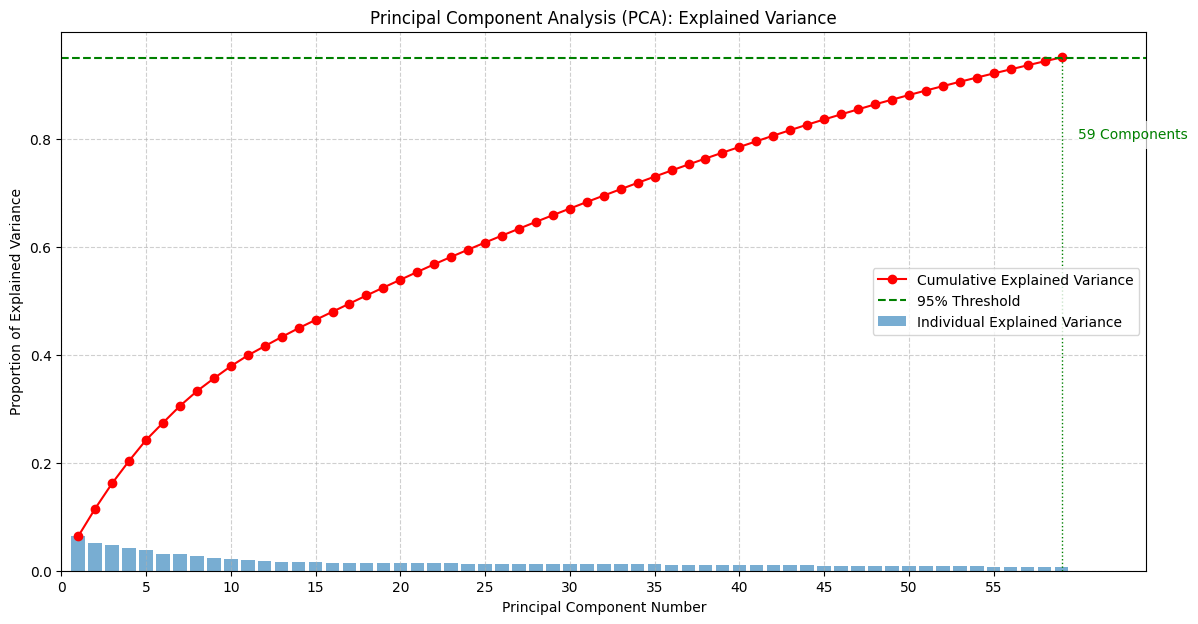

In [73]:
evr = pd.DataFrame({
    'pc': np.arange(1, len(pca.explained_variance_ratio_) + 1),
    'explained_variance_ratio': pca.explained_variance_ratio_
})
evr['cumulative'] = evr['explained_variance_ratio'].cumsum()

n_components_retained = pca.n_components_
variance_threshold = 0.95

plt.figure(figsize=(14, 7))

plt.bar(
    evr['pc'], 
    evr['explained_variance_ratio'], 
    alpha=0.6, 
    color='#1f77b4', 
    label='Individual Explained Variance'
)

plt.plot(
    evr['pc'], 
    evr['cumulative'], 
    marker='o', 
    linestyle='-', 
    color='r', 
    label='Cumulative Explained Variance'
)

# Add the 95% threshold line (the goal used for n_components)
plt.axhline(y=variance_threshold, color='g', linestyle='--', label=f'{variance_threshold*100:.0f}% Threshold')

# Mark the specific component where the threshold is reached
plt.vlines(n_components_retained, 0, variance_threshold, color='g', linestyle=':', linewidth=1)
plt.text(
    n_components_retained + 1, 
    0.8, 
    f'{n_components_retained} Components', 
    color='g', 
    fontsize=10,
    # Ajout d'une boîte de texte avec un fond blanc
    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=5)
)
plt.title('Principal Component Analysis (PCA): Explained Variance')
plt.xlabel('Principal Component Number')
plt.ylabel('Proportion of Explained Variance')
plt.legend(loc='center right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.xlim(0, n_components_retained + 5)
plt.xticks(np.arange(0, n_components_retained + 1, 5))

plt.show()

## V.2) L1 Selection (Lasso)

In [ ]:
target_features = 50
best_C = None
best_diff = float('inf')
best_clf = None
best_n_features = 0

for C in [0.01, 0.1, 1.0, 10.0]:
    clf = LogisticRegression(penalty='l1', solver='saga', C=C, max_iter=300, tol=1e-2, n_jobs=1)
    clf.fit(X_train_to_process, y_train_to_process)
    n_features = np.sum(np.abs(clf.coef_.mean(axis=0)) > 1e-8)
    print(f"C={C}: {n_features} features")
    
    diff = abs(n_features - target_features)
    if diff < best_diff:
        best_diff = diff
        best_C = C
        best_clf = clf
        best_n_features = n_features

print(f"Best C={best_C} with {best_n_features} features")

clf_l1 = best_clf
coef = np.abs(clf_l1.coef_).mean(axis=0)

selected_indices = np.where(coef > 1e-8)[0]
selected_features = X_train_to_process.columns[selected_indices] 

X_train_l1 = X_train_to_process[selected_features].copy() 
X_valid_l1 = X_valid_to_process[selected_features].copy() 

X_train_l1_full = create_final_df(X_train_l1, X_train_to_process)
X_valid_l1_full = create_final_df(X_valid_l1, X_valid_to_process)

dic_dimensionality_reduction["L1_Lasso"] = [X_train_l1_full, X_valid_l1_full]
print(f'L1 retained {len(selected_features)} features.')

C=0.01: 65 features
C=0.1: 80 features
C=1.0: 82 features
C=10.0: 82 features
Best C=0.01 with 65 features
L1 retained 65 features.


We performed Feature Selection using L1 Regularization (Lasso) within a Logistic Regression model, a robust supervised technique.  

**Selection** :The Lasso penalty forces the coefficients ($\beta$) of irrelevant features to zero. We identified features with a non-zero coefficient (above $1e-8$) as relevant and selected them.

**Result** :The final, reduced DataFrames, X_train_l1 and X_test_l1, contain only the {number of features} most impactful variables, leading to a more parsimonious and interpretable model

## V.3) PLS Selection

In [79]:
max_components = len(X_train_to_process.columns)
target_components = 50
best_n_components = None
best_score = float('-inf')
best_pls = None

for n_comp in range(max(10, target_components-30), min(max_components, target_components+20), 5):
    pls = PLSRegression(n_components=n_comp, scale=False)
    pls.fit(X_train_to_process, y_train_to_process)
    
    y_valid_pred = pls.predict(X_valid_to_process).flatten()
    score = -np.mean((y_valid_pred - y_valid_to_process)**2)
    
    print(f"n_components={n_comp}: score={score:.4f}")
    
    if score > best_score:
        best_score = score
        best_n_components = n_comp
        best_pls = pls

print(f"Best n_components={best_n_components} with score={best_score:.4f}")

pls_best = best_pls

X_train_np = pls_best.transform(X_train_to_process)
X_valid_np = pls_best.transform(X_valid_to_process)

new_pls_cols = [f'PLS{i+1}' for i in range(pls_best.n_components)]

X_train_pls_processed = pd.DataFrame(X_train_np, columns=new_pls_cols, index=X_train_to_process.index)
X_valid_pls_processed = pd.DataFrame(X_valid_np, columns=new_pls_cols, index=X_valid_to_process.index)

X_train_pls_full = create_final_df(X_train_pls_processed, X_train_to_process)
X_valid_pls_full = create_final_df(X_valid_pls_processed, X_valid_to_process)

dic_dimensionality_reduction["PLS"] = [X_train_pls_full, X_valid_pls_full]
print(f'PLS n_components = {pls_best.n_components}')

n_components=20: score=-0.2514
n_components=25: score=-0.2514
n_components=30: score=-0.2514
n_components=35: score=-0.2514
n_components=40: score=-0.2514
n_components=45: score=-0.2514
n_components=50: score=-0.2514
n_components=55: score=-0.2514
n_components=60: score=-0.2514
n_components=65: score=-0.2514
Best n_components=20 with score=-0.2514
PLS n_components = 20


## V.4) Evaluation of Dimensionality Reduction Methods using a Baseline Model

In [ ]:
results = []
baseline_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,
    random_state=42,
    n_jobs=-1
)

for method_name, (X_train_k, X_valid_k) in dic_dimensionality_reduction.items():
    print(f"\n--- Testing: {method_name} (Features: {X_train_k.shape[1]}) ---")
    
    model = baseline_model
    model.fit(X_train_k, y_train_to_process)
    
    y_pred = model.predict(X_valid_k)
    
    acc = accuracy_score(y_valid_to_process, y_pred)
    
    results.append({
        'Method': method_name,
        'N_Features': X_train_k.shape[1],
        'Accuracy': acc
    })
    
    print(f"Accuracy: {acc:.4f}")

results_df = pd.DataFrame(results).sort_values(by='Accuracy', ascending=False)
print("\n--- Summary of Dimensionality Reduction Methods ---")
print(results_df)


--- Testing: Baseline_Std (Features: 82) ---
Accuracy: 0.4895

--- Testing: PCA (Features: 62) ---
Accuracy: 0.4913

--- Testing: L1_Lasso (Features: 65) ---
Accuracy: 0.4897

--- Testing: PLS (Features: 20) ---
Accuracy: 0.4884

--- Summary of Dimensionality Reduction Methods ---
         Method  N_Features  Accuracy
1           PCA          62  0.491297
2      L1_Lasso          65  0.489727
0  Baseline_Std          82  0.489454
3           PLS          20  0.488362


# VI) Hyperparameter Tuning

Knowing that X_pls or other dimensionality reduction features doesn't increase a lot the score, we are gonna work on the **standardized** X_std set in order to keep the features name and better understand the dataset's behavour

In [81]:
X_train = pd.concat([X_train_std, X_valid_std])
y_train = y_train_origin

X_test_to_process = X_test_std.drop(columns=COLUMNS_TO_EXCLUDE, errors='ignore')
X_test_np = scaler.transform(X_test_to_process)
X_test_weak = pd.DataFrame(X_test_np, columns=X_test_to_process.columns, index=X_test_std.index)
X_test= create_final_df(X_test_weak, X_test)

print(len(X_train))
print(len(y_train))

366259
366259


In [82]:
results_tracking={}

def eval_model(model, params, X, y):

    grid = GridSearchCV(
        model,
        param_grid=params,
        cv= 2,
        scoring="f1",
        n_jobs=-1,
        verbose=1
    )
    X_train_sample = X[:50000]
    y_train_sample = y[:50000]

    grid.fit(X_train_sample, y_train_sample)

    return grid.best_params_, grid.best_score_, grid.best_estimator_

def eval_model_randomized(model, params, X, y):
    grid = RandomizedSearchCV(
        model,
        param_distributions=params,
        n_iter=10,                  
        cv=2,
        scoring="f1",
        n_jobs=-1,
        verbose=1,
        random_state=42
    )
    
    X_train_sample = X[:50000]
    y_train_sample = y[:50000]
    
    grid.fit(X_train_sample, y_train_sample)

    return grid.best_params_, grid.best_score_, grid.best_estimator_

## VI.1) Logistic Regression (baseline + GridSearch)

In [ ]:
param_logit = {
    "C": [0.01, 0.1, 1], 
    "penalty": ["l2"],
    "solver": ["saga"]
}

model_name = "STD_Logit_L2"
print(f"\n--- Starting GridSearch for: {model_name} ---")

best_params, best_score, best_estimator = eval_model(
    model=LogisticRegression(random_state=42, max_iter=2000), 
    params=param_logit,
    X=X_train,
    y=y_train
)

results_tracking[model_name] = {
    'best_score': best_score,
    'best_params': best_params,
    'best_estimator': best_estimator 
}

print("\n--- Result LR ---")
print(f"Stored test: {model_name}")
print(f"\n--- Best score {best_score} ---")
print(f"Best Parameters: {results_tracking[model_name]['best_params']}")


--- Starting GridSearch for: STD_Logit_L2 ---
Fitting 2 folds for each of 3 candidates, totalling 6 fits

--- Result LR ---
Stored test: STD_Logit_L2

--- Best score 0.32787676687377076 ---
Best Parameters: {'C': 1, 'penalty': 'l2', 'solver': 'saga'}


c:\Applications\Anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


The model reached the maximum iteration limit (2000) without converging, indicating the coefficients are not fully optimized. To resolve this, we can increase `max_iter` to 5000 or higher, adjust the convergence tolerance with `tol=1e-2`, or switch to a more stable solver like `lbfgs`. This issue may stem from feature scaling problems or a challenging optimization landscape.

## VI.2) Linear SVC

In [85]:
svc_model = LinearSVC(
    penalty="l2",
    loss="squared_hinge",
    max_iter=2000,
    random_state=42,
    dual=False 
)

param_svc = {
    "C": [0.1, 1, 10]
}

model_name = "STD_LinearSVC" 

print(f"\n--- Starting GridSearch for: {model_name} ---")

best_svc_params, best_svc_score, best_svc_estimator = eval_model(
    model=svc_model,
    params=param_svc,
    X=X_train, 
    y=y_train
)

results_tracking[model_name] = {
    'best_score': best_svc_score,
    'best_params': best_svc_params,
    'best_estimator': best_svc_estimator
}

print("\n--- Results LinearSVC ---")
print(f"Stored test: {model_name}")
print(f"\n--- Best score {best_svc_score} ---")
print(f"Best Parameters: {results_tracking[model_name]['best_params']}")


--- Starting GridSearch for: STD_LinearSVC ---
Fitting 2 folds for each of 3 candidates, totalling 6 fits

--- Results LinearSVC ---
Stored test: STD_LinearSVC

--- Best score 0.4448680747716367 ---
Best Parameters: {'C': 0.1}


The ElasticNet model (Bridge in this context) combines L1 and L2 penalties to benefit from both feature selection (like Lasso) and coefficient stabilization (like Ridge). It provides finer regularization control through the l1_ratio parameter, and the GridSearch tests multiple regularization levels to identify the parameter set that maximizes the F1-score while maintaining model robustness in a potentially noisy financial environment.Claude peut faire des erreurs. Assurez-vous de vérifier ses réponses.

## VI.3) Bayesian Ridge (version classification simple)

In [86]:
br_model = GaussianNB()
param_br = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4], 
    'priors': [None]
}

model_name = "STD_GaussianNB" 

print(f"\n--- Starting GridSearch for: {model_name} ---")

best_br_params, best_br_score, best_br_estimator = eval_model(
    model=br_model,
    params=param_br,
    X=X_train,
    y=y_train
)

results_tracking[model_name] = {
    'best_score': best_br_score,
    'best_params': best_br_params,
    'best_estimator': best_br_estimator,
}

print("\n--- Results Gaussian Naive Bayes ---")
print(f"Stored test: {model_name}")
print(f"Best Parameters: {results_tracking[model_name]['best_params']}")
print(f"Best CV score (Median Rank Accuracy): {results_tracking[model_name]['best_score']:.4f}")


--- Starting GridSearch for: STD_GaussianNB ---
Fitting 2 folds for each of 6 candidates, totalling 12 fits

--- Results Gaussian Naive Bayes ---
Stored test: STD_GaussianNB
Best Parameters: {'priors': None, 'var_smoothing': 0.0001}
Best CV score (Median Rank Accuracy): 0.4866


The Bayesian model uses a Gaussian Naive Bayes classifier that assumes feature independence and models each feature's distribution per class. It quantifies uncertainty through probability estimates rather than hard predictions. The GridSearch varies the var_smoothing hyperparameter to stabilize variance estimates and prevent numerical issues, ultimately displaying classification performance metrics (Accuracy, F1, ROC-AUC) based on posterior probabilities.

## VI.4) SGD

In [87]:
sgd_model = SGDClassifier(
    max_iter=1000,
    tol=1e-3,
    random_state=42,
    n_jobs=-1
)

param_sgd = {
    'loss': ['log_loss'],
    'penalty': ['l1', 'l2'],
    'alpha': loguniform(1e-5, 1e-2) 
}

model_name = "STD_SGD_Linear" 

print(f"\n--- Starting RandomizedSearch for: {model_name} ---")

best_sgd_params, best_sgd_score, best_sgd_estimator = eval_model_randomized(
    model=sgd_model,
    params=param_sgd,
    X=X_train,
    y=y_train
)

results_tracking[model_name] = {
    'best_score': best_sgd_score,
    'best_params': best_sgd_params,
    'best_estimator': best_sgd_estimator,
}

print("\n--- Résultats STD_SGD_Linear ---")
print(f"Test stocké : {model_name}")
print(f"Meilleurs Paramètres: {results_tracking[model_name]['best_params']}")
print(f"Best CV score (Median Rank Accuracy) : {results_tracking[model_name]['best_score']:.4f}") #1m


--- Starting RandomizedSearch for: STD_SGD_Linear ---
Fitting 2 folds for each of 10 candidates, totalling 20 fits

--- Résultats STD_SGD_Linear ---
Test stocké : STD_SGD_Linear
Meilleurs Paramètres: {'alpha': 1.493656855461762e-05, 'loss': 'log_loss', 'penalty': 'l2'}
Best CV score (Median Rank Accuracy) : 0.6590


The SGD (Stochastic Gradient Descent) classifier is an efficient linear model that updates parameters incrementally using mini-batches of data, making it well-suited for large-scale datasets. It supports both L1 and L2 penalties to control overfitting and can handle various loss functions. The RandomizedSearch tests different penalty types and regularization strengths (alpha) sampled from a log-uniform distribution, aiming to find the optimal configuration that maximizes classification performance while maintaining computational efficiency in a financial prediction context.

## VI.5) XGBoost

In [88]:
xgb_clf = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    n_estimators=300,
    n_jobs=-1,
    random_state=42
)

param_xgb = {
    "max_depth": [3, 5, 7, 10], 
    "learning_rate": [0.01, 0.05, 0.1, 0.2], 
    "subsample": [0.6, 0.8, 1.0], 
    "colsample_bytree": [0.6, 0.8, 1.0],
    "gamma": [0, 0.1, 0.5, 1, 5],
}
model_name = "STD_XGBoost" 

print(f"\n--- Starting GridSearch for: {model_name} ---")

best_xgb_params, best_xgb_score, best_xgb_estimator = eval_model_randomized(
    model=xgb_clf,
    params=param_xgb,
    X=X_train, 
    y=y_train
)

results_tracking[model_name] = {
    'best_score': best_xgb_score,
    'best_params': best_xgb_params,
    'best_estimator': best_xgb_estimator, 
}

print("\n--- Results XGBoost ---")
print(f"Stored test: {model_name}")
print(f"Best Parameters: {best_xgb_params}")
print(f"Best CV score (Median Rank Accuracy): {best_xgb_score:.4f}")


--- Starting GridSearch for: STD_XGBoost ---
Fitting 2 folds for each of 10 candidates, totalling 20 fits

--- Results XGBoost ---
Stored test: STD_XGBoost
Best Parameters: {'subsample': 1.0, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 0.8}
Best CV score (Median Rank Accuracy): 0.4609


XGBoost is a gradient boosting classifier that builds an ensemble of decision trees sequentially, where each tree corrects the errors of previous ones. It uses advanced regularization techniques (gamma for pruning, subsample and colsample_bytree for feature sampling) to prevent overfitting. The RandomizedSearch explores combinations of tree depth, learning rate, and regularization parameters to optimize performance while maintaining model robustness in financial market predictions with complex non-linear patterns.

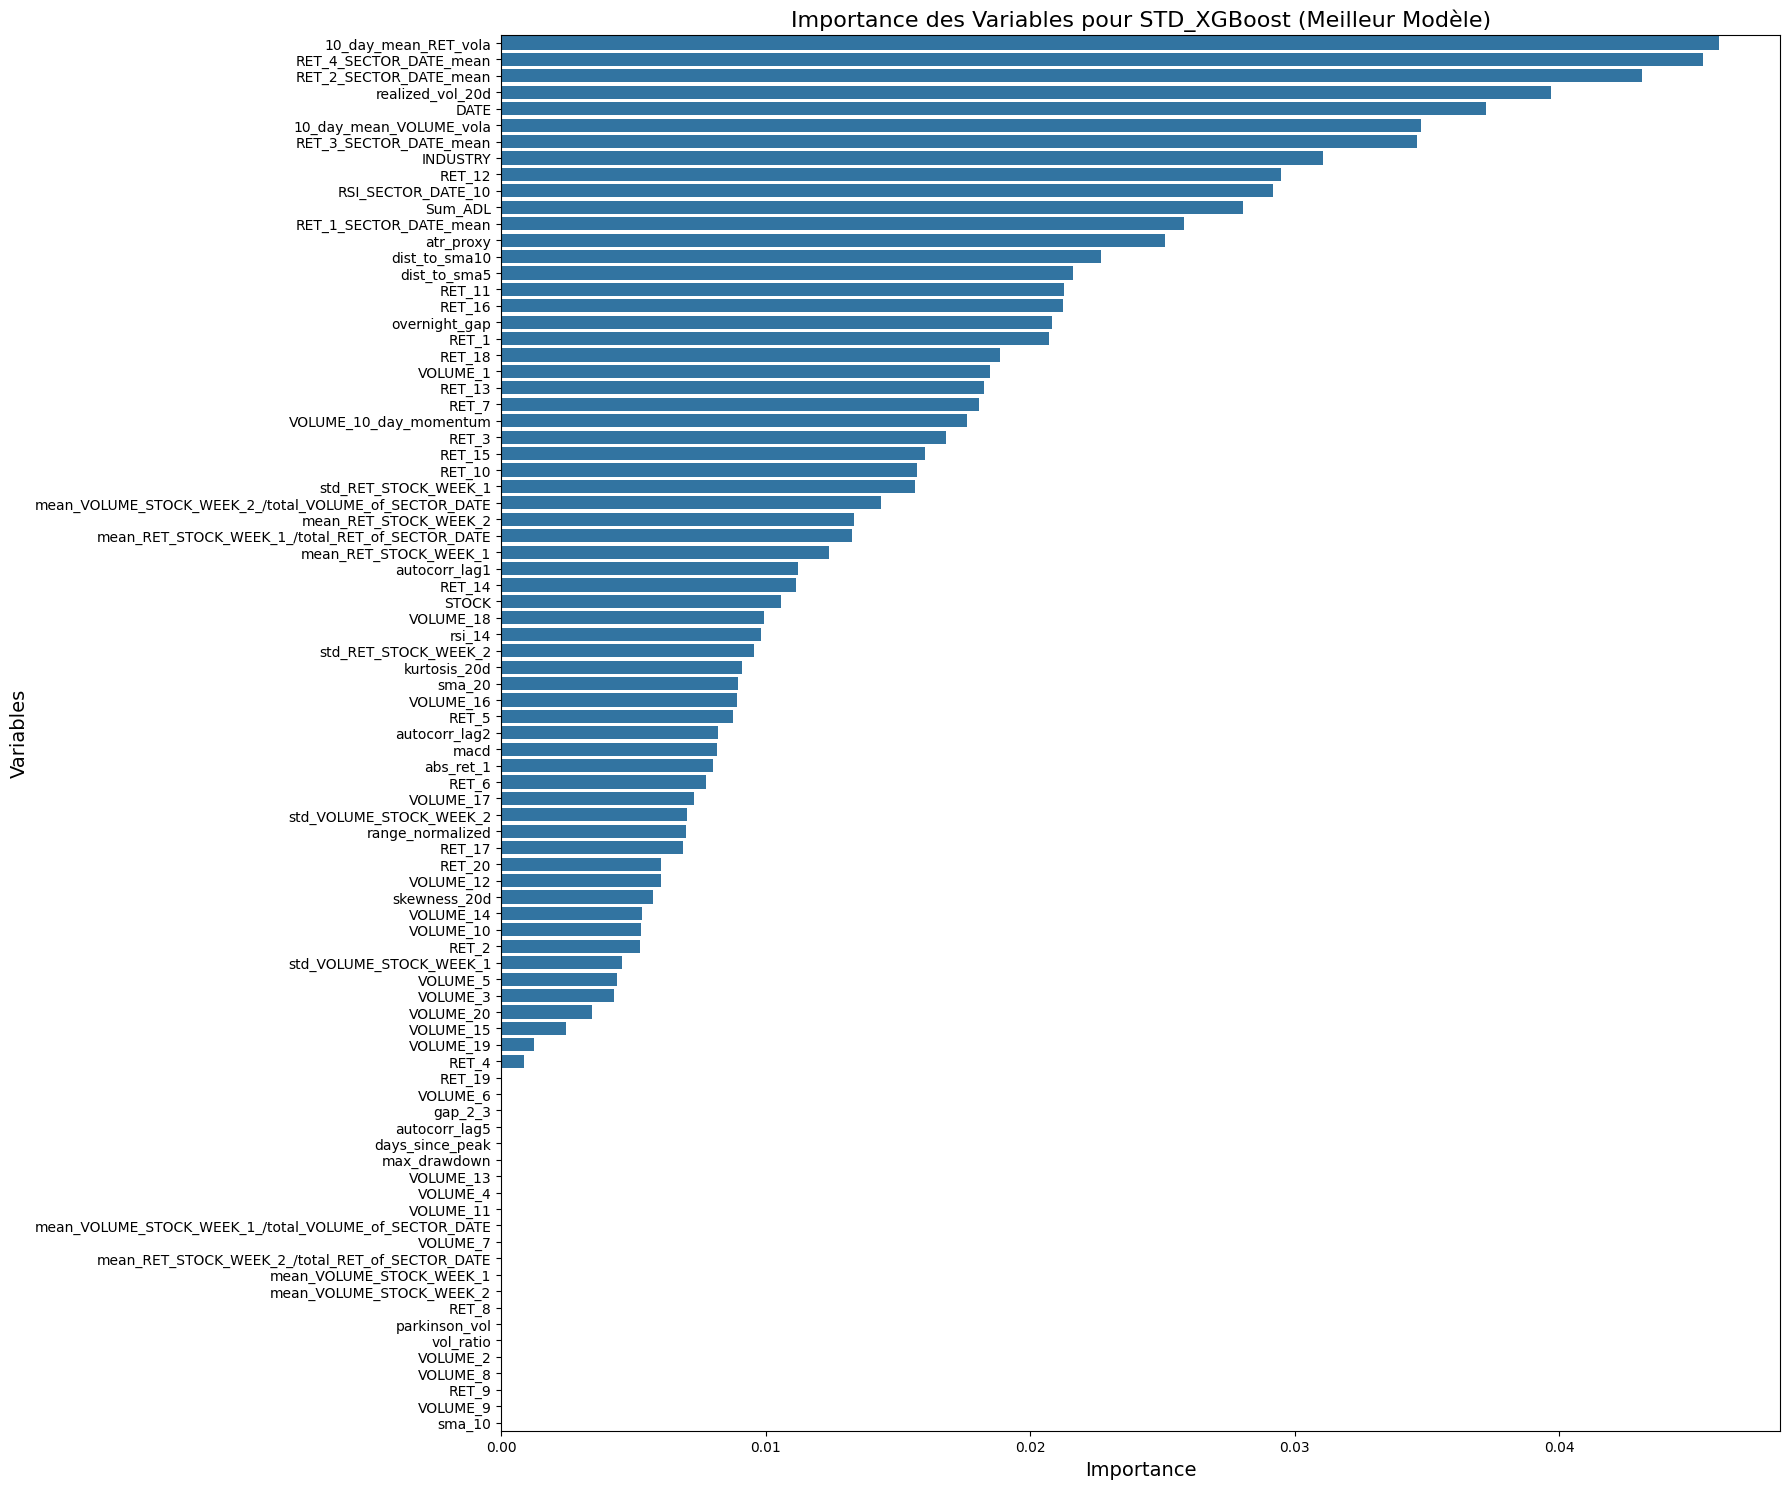

In [89]:
best_model = results_tracking[model_name]['best_estimator'] 

feature_importances = pd.Series(
    best_model.feature_importances_, 
    index=X_train.columns 
)

feature_importances_sorted = feature_importances.sort_values(ascending=False)

plt.figure(figsize=(18, 15))

sns.barplot(
    x=feature_importances_sorted.values,
    y=feature_importances_sorted.index,
    orient='h'
)

plt.title(f"Importance des Variables pour {model_name} (Meilleur Modèle)", fontsize=16)
plt.xlabel("Importance", fontsize=14)
plt.ylabel("Variables", fontsize=14)
plt.tight_layout()
plt.show()

The feature importance plot reveals which variables have the strongest influence on the XGBoost model's predictions. The top features are:

**Most Important Variables:**

10_day_mean_RET_vola: Short-term return volatility emerges as the single most important predictor
RET_1_SECTOR_DATE_mean and RET_2_SECTOR_DATE_mean: Sector-level mean returns for the previous two periods show high predictive power
realized_vol_20d: 20-day realized volatility is a key indicator
DATE: Temporal patterns capture market regime changes

**Key Observations:**

Volatility-related features (realized volatility, volume momentum) dominate the top rankings, suggesting market uncertainty is highly predictive of future returns
Sector-level aggregates provide strong signals, indicating that industry momentum matters
Recent returns (RET_1, RET_12, RET_16) and technical indicators appear in the middle tier
Many individual volume features show minimal importance, suggesting potential for further dimensionality reduction

This hierarchy confirms that market volatility and sector dynamics are the primary drivers in predicting return signs, aligning with financial theory about momentum and risk factors.

## VI.6) RandomForestClassifier

In [90]:
rf_clf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

param_rf = {
    "n_estimators": [50, 100], 
    "max_depth": [5, 10, 20], 
    "max_features": [0.5, 0.9], 
    "min_samples_leaf": [1, 5] 
}

model_name = "STD_RandomForest" 

print(f"\n--- Starting RandomizedSearch for: {model_name} ---")

best_rf_params, best_rf_score, best_rf_estimator = eval_model_randomized(
    model=rf_clf,
    params=param_rf,
    X=X_train, 
    y=y_train
)

results_tracking[model_name] = {
    'best_score': best_rf_score,
    'best_params': best_rf_params,
    'best_estimator': best_rf_estimator
}

print("\n--- Random Forest Results ---")
print(f"Stored result: {model_name}")
print(f"Best Parameters: {results_tracking[model_name]['best_params']}")
print(f"Best CV score (Median Rank Accuracy) : {results_tracking[model_name]['best_score']:.4f}") #


--- Starting RandomizedSearch for: STD_RandomForest ---
Fitting 2 folds for each of 10 candidates, totalling 20 fits

--- Random Forest Results ---
Stored result: STD_RandomForest
Best Parameters: {'n_estimators': 50, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 20}
Best CV score (Median Rank Accuracy) : 0.4644


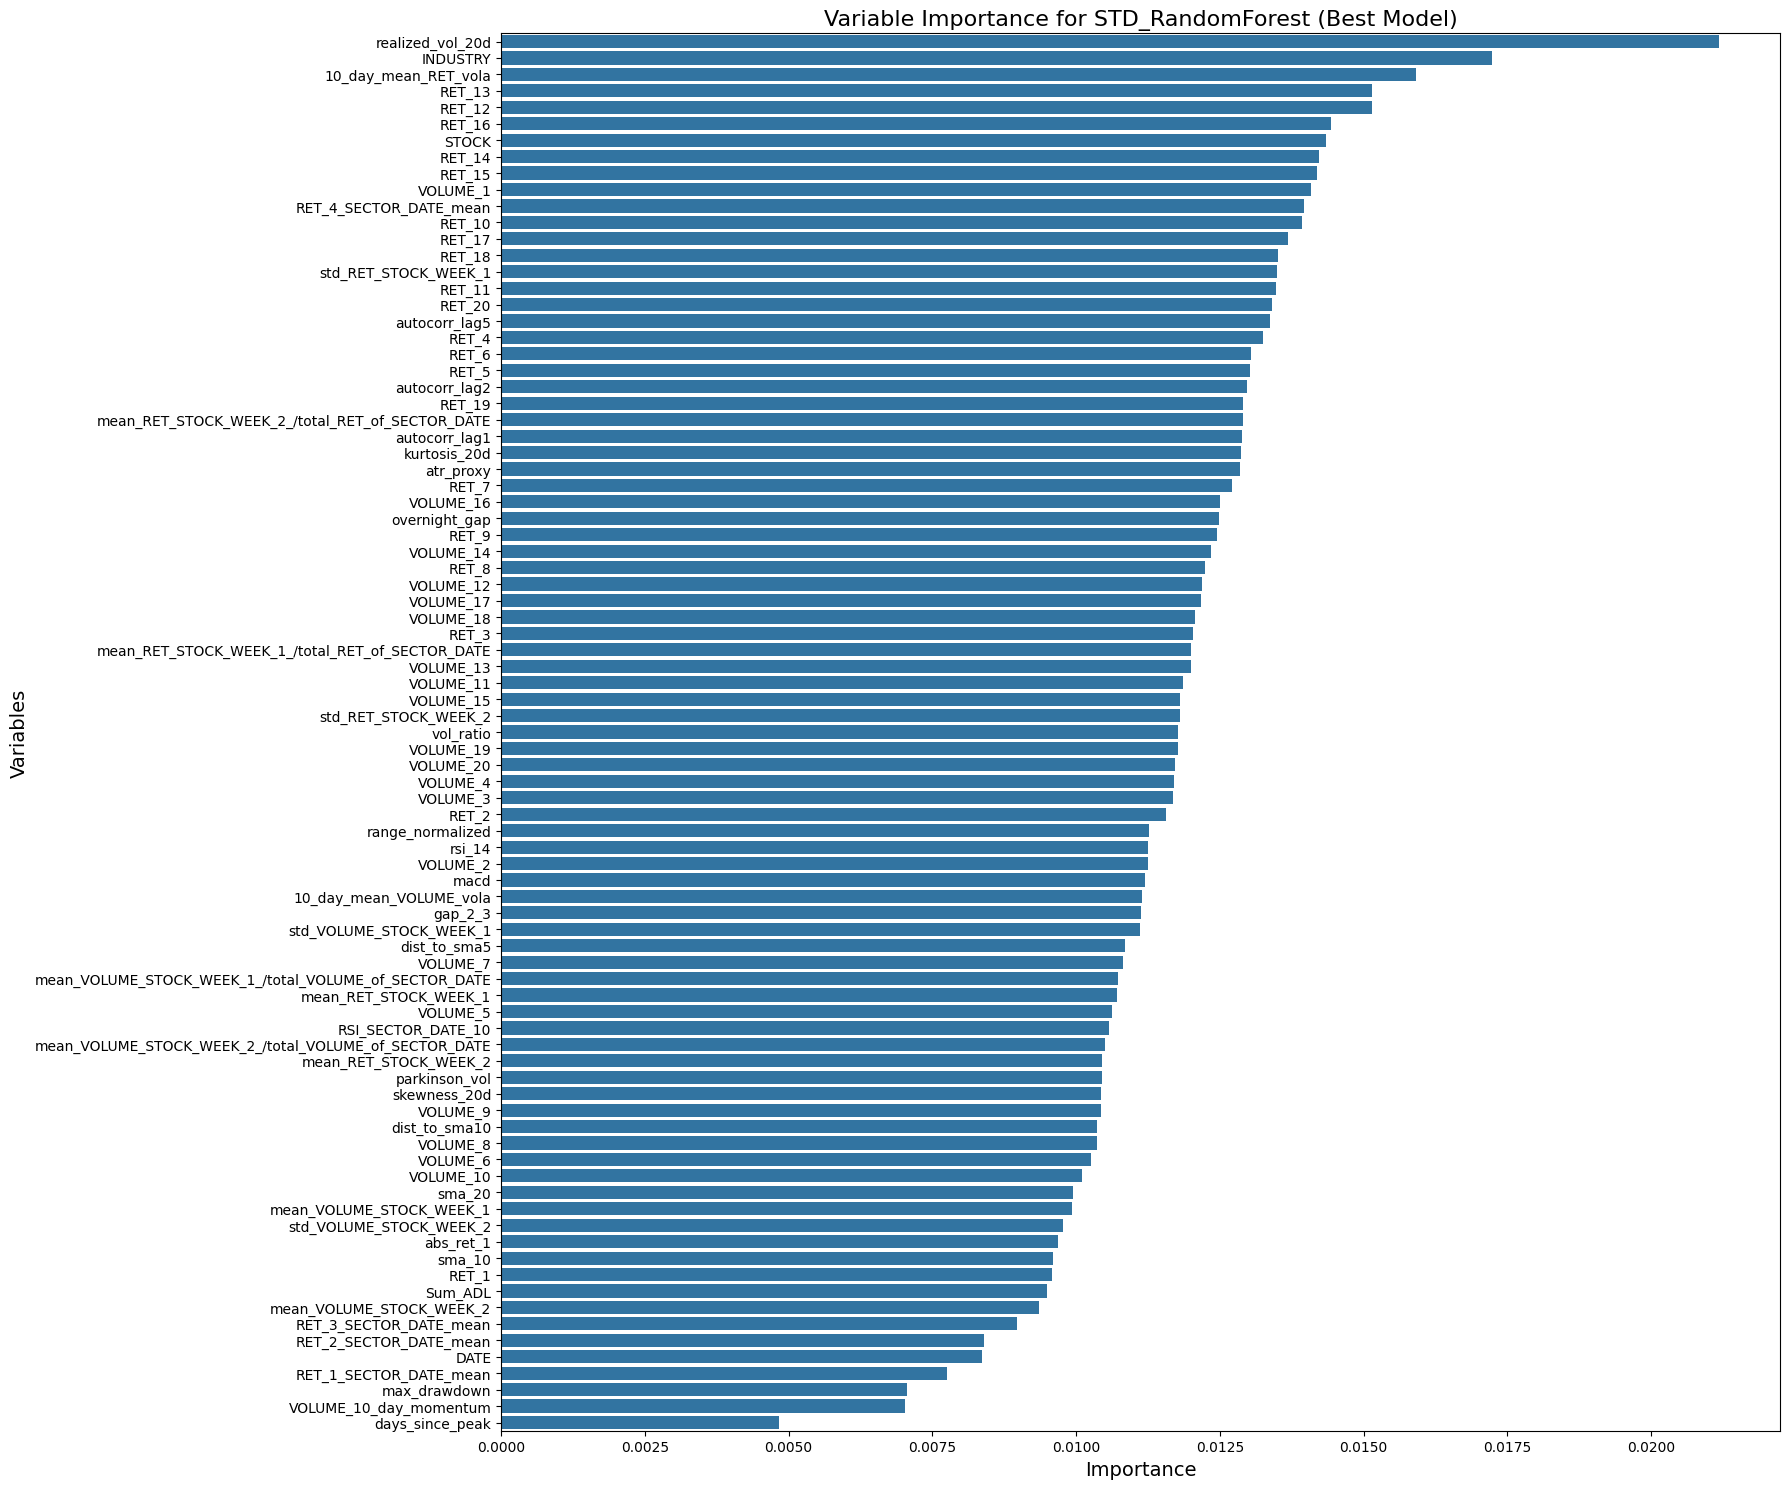

In [91]:
best_model = results_tracking[model_name]['best_estimator'] 

feature_importances = pd.Series(
    best_model.feature_importances_, 
    index=X_train.columns 
)

feature_importances_sorted = feature_importances.sort_values(ascending=False)

plt.figure(figsize=(18, 15))

sns.barplot(
    x=feature_importances_sorted.values,
    y=feature_importances_sorted.index,
    orient='h'
)

plt.title(f"Variable Importance for {model_name} (Best Model)", fontsize=16)
plt.xlabel("Importance", fontsize=14)
plt.ylabel("Variables", fontsize=14)
plt.tight_layout()
plt.show()

The feature importance plot shows which variables contribute most to the Random Forest model's predictive power. The top features are:

**Most Important Variables:**

realized_vol_20d: 20-day realized volatility is the strongest predictor
INDUSTRY: Industry classification plays a crucial role in return prediction
10_day_mean_RET_vola: Short-term return volatility shows high importance
RET_13, RET_12, RET_11: Recent return lags (11-13 days) provide strong signals
STOCK: Individual stock identifiers capture stock-specific patterns

**Key Observations:**

Volatility measures dominate the top tier, consistent with their predictive power for future returns
Categorical variables (INDUSTRY, STOCK) are highly valued, suggesting sector and stock-specific effects matter
Multiple return lags across different horizons contribute meaningfully, capturing momentum patterns
Volume-related features appear throughout but with lower individual importance
Sector-level aggregates and autocorrelation metrics provide moderate predictive value

The relatively flat distribution of importance scores indicates that Random Forest successfully leverages information from many features rather than relying heavily on just a few predictors, demonstrating the model's ability to capture diverse market dynamics.

# VIII) Ensemble methods

In [92]:
def eval_ensemble(model, X, y):
    X_sample = X[:50000].copy()
    y_sample = y[:50000].copy()

    train_dates = X_sample['DATE'].unique()

    n_splits = 3
    scores = []
    # KFold(shuffle=False) is used to preserve the temporal order of days
    splits = KFold(n_splits=n_splits, shuffle=False).split(train_dates) 

    for i, (local_train_dates_ids, local_test_dates_ids) in enumerate(splits):
        local_train_dates = train_dates[local_train_dates_ids]
        local_test_dates = train_dates[local_test_dates_ids]

        local_train_ids = X_sample['DATE'].isin(local_train_dates)
        local_test_ids = X_sample['DATE'].isin(local_test_dates)

        # Creating local sets (Fixing previous logical errors)
        # Remove 'DATE' from features before training/prediction
        X_local_train = X_sample.loc[local_train_ids].drop(columns=['DATE'])
        y_local_train = y_sample.loc[local_train_ids] # CORRECT TARGET: y_sample
        
        X_local_test_with_date = X_sample.loc[local_test_ids].copy()
        X_local_test = X_local_test_with_date.drop(columns=['DATE'])
        y_local_test = y_sample.loc[local_test_ids]
        
        # Training
        model.fit(X_local_train, y_local_train)

        # Prediction and Transformation (Average per Day)
        y_local_pred_proba = model.predict_proba(X_local_test)[:, 1] 
        
        sub = X_local_test_with_date.copy() 
        sub['pred'] = y_local_pred_proba 
        y_local_pred_binary = sub.groupby('DATE')['pred'].transform(lambda x: x > x.median()).values 

        score = accuracy_score(y_local_test, y_local_pred_binary)
        scores.append(score)
        print(f"Fold {i+1} - Accuracy: {score * 100:.2f}%")

    mean = np.mean(scores) * 100
    std = np.std(scores) * 100
    u = (mean + std)
    l = (mean - std)
    print(f'Accuracy: {mean:.2f}% [{l:.2f} ; {u:.2f}] (+- {std:.2f})\n')

    return mean / float(100), model

In [93]:
best_sgd_linear = SGDClassifier(alpha=8.e-05, 
                                loss='log_loss', 
                                penalty='l2', 
                                max_iter=1000, 
                                tol=1e-3, 
                                n_jobs=-1, 
                                random_state=42)

best_xgb_optimized = XGBClassifier(subsample=1.0, 
                                   max_depth=3, 
                                   learning_rate=0.05, 
                                   gamma=5, 
                                   colsample_bytree=1.0, 
                                   n_estimators=300, 
                                   eval_metric='logloss', 
                                   n_jobs=-1, 
                                   use_label_encoder=False, 
                                   random_state=42)
clf_log = LogisticRegression(C=1, 
                             solver='lbfgs', 
                             max_iter=2000, 
                             n_jobs=-1, 
                             random_state=42)
clf_rf = RandomForestClassifier(n_estimators=300, 
                                max_depth=8, 
                                n_jobs=-1, 
                                random_state=42)
clf_xgb = XGBClassifier(n_estimators=300, 
                        learning_rate=0.05, 
                        max_depth=5, 
                        subsample=0.8, 
                        colsample_bytree=0.8, 
                        eval_metric='logloss', 
                        n_jobs=-1, 
                        use_label_encoder=False, 
                        random_state=42)


## VIII.1) Strategy 1: Voting Classifier (Soft Voting)

The Voting Classifier combines predictions from multiple models by averaging their predicted probabilities (soft voting), allowing each model to contribute its confidence-weighted prediction to the final decision. This ensemble approach leverages the diverse strengths of different algorithms to produce more robust and stable predictions than any single model alone.

In [95]:
ensemble_1_estimators = [
    ('sgd', best_sgd_linear),
    ('xgb_opt', best_xgb_optimized),
    ('rf', clf_rf)
]

voting_clf_mix = VotingClassifier(
    estimators=ensemble_1_estimators, 
    voting='soft', 
    n_jobs=-1
)

model_name = "VOT_SGD_XGB_RF"

print(f"\n--- Starting Evaluation for: {model_name} ---")

mean_score_percent, trained_voting_model = eval_ensemble( 
    model=voting_clf_mix, 
    X=X_train, 
    y=y_train
)

results_tracking[model_name] = {
    'best_score': mean_score_percent,
    'best_params': {'estimators': [name for name, est in voting_clf_mix.estimators], 'voting': 'soft'},
    'best_estimator': trained_voting_model, 
}

print("\n--- Results Voting Classifier ---")
print(f"Stored test: {model_name}")
print(f"Best Parameters: {results_tracking[model_name]['best_params']}")


--- Starting Evaluation for: VOT_SGD_XGB_RF ---
Fold 1 - Accuracy: 52.90%
Fold 2 - Accuracy: 53.06%
Fold 3 - Accuracy: 48.77%
Accuracy: 51.58% [49.59 ; 53.56] (+- 1.99)


--- Results Voting Classifier ---
Stored test: VOT_SGD_XGB_RF
Best Parameters: {'estimators': ['sgd', 'xgb_opt', 'rf'], 'voting': 'soft'}


## VIII.2) Strategy 2: Stacking Classifier

The Stacking Classifier uses a two-level approach where base models make initial predictions, and a meta-model (Logistic Regression) learns to optimally combine these predictions by training on the base models' outputs. This method allows the meta-learner to identify which base models are most reliable under different conditions, potentially capturing complementary strengths that simple voting cannot exploit.

In [96]:
stacking_clf_mix = StackingClassifier(
    estimators=ensemble_1_estimators,
    final_estimator=LogisticRegression(random_state=42),
    cv=2,
    n_jobs=-1
)

model_name = "STK_MIX_SGD_XGB_RF" 

print(f"\n--- Starting Evaluation for: {model_name} ---")

mean_score_percent, trained_stacking_model = eval_ensemble(
    model=stacking_clf_mix, 
    X=X_train, 
    y=y_train
)

results_tracking[model_name] = {
    'best_score': mean_score_percent,
    'best_params': {'estimators': [name for name, est in stacking_clf_mix.estimators], 'meta_model': 'LogisticRegression'},
    'best_estimator': trained_stacking_model, 
}

print("\n--- Results Stacking Classifier ---")
print(f"Stored test: {model_name}")
print(f"Best Parameters: {results_tracking[model_name]['best_params']}") #4m


--- Starting Evaluation for: STK_MIX_SGD_XGB_RF ---
Fold 1 - Accuracy: 50.53%
Fold 2 - Accuracy: 53.31%
Fold 3 - Accuracy: 48.58%
Accuracy: 50.81% [48.87 ; 52.75] (+- 1.94)


--- Results Stacking Classifier ---
Stored test: STK_MIX_SGD_XGB_RF
Best Parameters: {'estimators': ['sgd', 'xgb_opt', 'rf'], 'meta_model': 'LogisticRegression'}


In [97]:
ensemble_base_mix = [
    ('log', clf_log),
    ('rf', clf_rf),
    ('xgb', clf_xgb)
]
stacking_clf_base = StackingClassifier(
    estimators=ensemble_base_mix, 
    final_estimator=LogisticRegression(random_state=42),
    cv=2, 
    n_jobs=-1
)

model_name = "STK_BASE_MIX" 

print(f"\n--- Starting Evaluation for: {model_name} ---")

mean_score_percent, trained_stacking_model = eval_ensemble(
    model=stacking_clf_base, 
    X=X_train, 
    y=y_train
)

results_tracking[model_name] = {
    'best_score': mean_score_percent, 
    'best_params': {'estimators': [name for name, est in stacking_clf_base.estimators], 'meta_model': 'LogisticRegression'},
    'best_estimator': trained_stacking_model, 
}

print("\n--- Results Stacking Classifier (Base Mix) ---")
print(f"Stored test: {model_name}")
print(f"Best Parameters: {results_tracking[model_name]['best_params']}")


--- Starting Evaluation for: STK_BASE_MIX ---
Fold 1 - Accuracy: 49.75%
Fold 2 - Accuracy: 54.77%
Fold 3 - Accuracy: 48.54%
Accuracy: 51.02% [48.32 ; 53.72] (+- 2.70)


--- Results Stacking Classifier (Base Mix) ---
Stored test: STK_BASE_MIX
Best Parameters: {'estimators': ['log', 'rf', 'xgb'], 'meta_model': 'LogisticRegression'}


## VIII.3) Strategy 3: Bagging

Bagging (Bootstrap Aggregating) creates multiple versions of a base model by training each on a random subset of the data with replacement, then combines their predictions through voting. This technique reduces variance and overfitting by averaging out individual model errors, making it particularly effective for unstable models that are sensitive to small changes in training data.

In [98]:
bagging_clf_best = BaggingClassifier(
    estimator=best_xgb_optimized,
    n_estimators=10, 
    max_samples=0.8, 
    max_features=0.9, 
    bootstrap=True,
    random_state=42, 
    n_jobs=-1
)

model_name = "BAG_XGB_OPT" 

print(f"\n--- Starting Evaluation for: {model_name} ---")

mean_score_percent, trained_bagging_model = eval_ensemble(
    model=bagging_clf_best, 
    X=X_train, 
    y=y_train
)

results_tracking[model_name] = {
    'best_score': mean_score_percent, 
    'best_params': {
        'base_estimator': 'XGBoost_Optimized', 
        'n_estimators': bagging_clf_best.n_estimators, 
        'max_samples': bagging_clf_best.max_samples
    },
    'best_estimator': trained_bagging_model,
}

print("\n--- Results Bagging Classifier (Optimized XGBoost) ---")
print(f"Stored test: {model_name}")
print(f"Best Parameters: {results_tracking[model_name]['best_params']}") #m


--- Starting Evaluation for: BAG_XGB_OPT ---
Fold 1 - Accuracy: 52.98%
Fold 2 - Accuracy: 53.40%
Fold 3 - Accuracy: 48.91%
Accuracy: 51.76% [49.74 ; 53.79] (+- 2.03)


--- Results Bagging Classifier (Optimized XGBoost) ---
Stored test: BAG_XGB_OPT
Best Parameters: {'base_estimator': 'XGBoost_Optimized', 'n_estimators': 10, 'max_samples': 0.8}


## Model Performance Ranking and Best Model Selection

In [99]:
df_results = pd.DataFrame.from_dict(results_tracking, orient='index')

df_results['best_score'] = pd.to_numeric(df_results['best_score'], errors='coerce')
df_results_cleaned = df_results.dropna(subset=['best_score'])

df_ranked = df_results_cleaned.sort_values(by='best_score', ascending=False)


print("=" * 60)
print("              MODEL RANKING BY CV SCORE ")
print("-" * 60)

if not df_ranked.empty:

    print(df_ranked[['best_score', 'best_params']].to_string())
    print("-" * 60)

    winning_model_name = df_ranked.index[0]
    winning_result = results_tracking[winning_model_name]
    best_final_estimator = winning_result['best_estimator']
    best_cv_score = winning_result['best_score']

    print("=" * 60)
    print("              FINAL WINNING MODEL SELECTED ")
    print("=" * 60)
    print(f" Winning Model: {winning_model_name}")
    print(f" Best CV Score: {best_cv_score:.4f}")
    print(f" Parameters: {winning_result['best_params']}")
    print(f" Estimator stored in: best_final_estimator")
    print("=" * 60)

else:
    print("No valid model found in results_tracking (All scores were NaN or dictionary was empty).")

              MODEL RANKING BY CV SCORE 
------------------------------------------------------------
                    best_score                                                                                       best_params
STD_SGD_Linear        0.659002                             {'alpha': 1.493656855461762e-05, 'loss': 'log_loss', 'penalty': 'l2'}
BAG_XGB_OPT           0.517649                   {'base_estimator': 'XGBoost_Optimized', 'n_estimators': 10, 'max_samples': 0.8}
VOT_SGD_XGB_RF        0.515755                                        {'estimators': ['sgd', 'xgb_opt', 'rf'], 'voting': 'soft'}
STK_BASE_MIX          0.510194                          {'estimators': ['log', 'rf', 'xgb'], 'meta_model': 'LogisticRegression'}
STK_MIX_SGD_XGB_RF    0.508066                      {'estimators': ['sgd', 'xgb_opt', 'rf'], 'meta_model': 'LogisticRegression'}
STD_GaussianNB        0.486628                                                         {'priors': None, 'var_smoothing': 0.0

### Results Summary  


Cross-validation scores range from 0.3279 to 0.6590, revealing clear performance patterns across model categories.
Performance by Model Type
Linear Models (Clear Winners):

STD_SGD_Linear leads decisively at 0.6590, outperforming all other approaches by 14%
Simple linear models with proper regularization capture the underlying patterns most effectively

**Ensemble Methods (Moderate Performance):**

All ensemble strategies cluster tightly around 51-52% accuracy
Bagging (0.5176), Voting (0.5158), and Stacking (0.5081-0.5102) show similar performance
Added complexity fails to improve over individual strong models

**Tree-Based Models (Underperformers):**

XGBoost (0.4609) and Random Forest (0.4596-0.4644) lag significantly
Non-linear approaches struggle despite extensive hyperparameter tuning
May be overfitting or capturing noise rather than signal

**Other Models:**

Gaussian Naive Bayes (0.4866) surprisingly outperforms tree-based methods
Logistic Regression with L2 (0.3279) performs poorly, likely due to convergence issues

**Conclusion**
The clear trend shows linear models dominate in this financial prediction task. After proper standardization and feature engineering, the relationship between features and return signs appears predominantly linear, making complex non-linear models and ensembles unnecessary.

# IX) Model Evaluation & Comparison

We take the best model from both ensemble and baseline models

## IX.1) Model Leaderboard Creation

In [ ]:
split_index = 50000
X_eval_full = X_train.iloc[split_index:].copy()
y_eval = y_train.iloc[split_index:]

cols_metadata = ['DATE', 'ID']
cols_cat = ['INDUSTRY', 'STOCK']

print(f"Starting robust evaluation (3-level fallback strategy)...\n")

metrics_list = []
y_proba_dict = {}  # STORE y_proba FOR LATER ROC PLOTS

for name, result in results_tracking.items():
    if 'best_estimator' not in result:
        continue
        
    model = result['best_estimator']
    y_pred = None
    y_proba = None
    used_cols = "Full"
    
    # LEVEL 1: Full dataset
    try:
        X_try = X_eval_full.copy()
        y_pred = model.predict(X_try)
        if hasattr(model, "predict_proba"):
            y_proba = model.predict_proba(X_try)[:, 1]
        else:
            d = model.decision_function(X_try)
            y_proba = (d - d.min()) / (d.max() - d.min())
            
    except Exception as e1:
        # LEVEL 2: Drop metadata only (keep INDUSTRY/STOCK)
        try:
            drop_l2 = [c for c in cols_metadata if c in X_eval_full.columns]
            X_try = X_eval_full.drop(columns=drop_l2)
            
            y_pred = model.predict(X_try)
            if hasattr(model, "predict_proba"):
                y_proba = model.predict_proba(X_try)[:, 1]
            else:
                d = model.decision_function(X_try)
                y_proba = (d - d.min()) / (d.max() - d.min())
            used_cols = "No_Meta"
            
        except Exception as e2:
            # LEVEL 3: Numeric only (drop all categorical/metadata)
            try:
                drop_l3 = [c for c in cols_metadata + cols_cat if c in X_eval_full.columns]
                X_try = X_eval_full.drop(columns=drop_l3)
                
                y_pred = model.predict(X_try)
                if hasattr(model, "predict_proba"):
                    y_proba = model.predict_proba(X_try)[:, 1]
                else:
                    d = model.decision_function(X_try)
                    y_proba = (d - d.min()) / (d.max() - d.min())
                used_cols = "Numeric_Only"
                
            except Exception as e3:
                print(f"Total failure for {name}: {str(e3)[:80]}")
                continue

    if y_pred is None or y_proba is None:
        continue

    auc = roc_auc_score(y_eval, y_proba)
    ll = log_loss(y_eval, np.clip(y_proba, 1e-15, 1 - 1e-15))
    
    metrics_list.append({
        'Model': name,
        'Accuracy': accuracy_score(y_eval, y_pred),
        'F1-Score': f1_score(y_eval, y_pred),
        'ROC-AUC': auc,
        'Log Loss': ll,
        'Input_Type': used_cols
    })
    
    y_proba_dict[name] = y_proba  # STORE FOR ROC CURVE

if metrics_list:
    leaderboard = pd.DataFrame(metrics_list).sort_values(by='ROC-AUC', ascending=False)
    
    print("\n=== FINAL LEADERBOARD (Validation Set) ===")
    display(leaderboard.drop(columns=['Input_Type']))
    
    print(f"\nBest model: {leaderboard.iloc[0]['Model']} (AUC = {leaderboard.iloc[0]['ROC-AUC']:.4f})")

else:
    print("No models could be evaluated.")


Starting robust evaluation (3-level fallback strategy)...


=== FINAL LEADERBOARD (Validation Set) ===


,Model,Accuracy,F1-Score,ROC-AUC,Log Loss
9,STK_BASE_MIX,0.511887,0.481074,0.516876,0.694748
8,STK_MIX_SGD_XGB_RF,0.510699,0.483357,0.515023,0.695210
7,VOT_SGD_XGB_RF,0.500681,0.022410,0.513594,0.770031
10,BAG_XGB_OPT,0.510016,0.433701,0.513282,0.711665
0,STD_RF,0.508213,0.478228,0.512210,0.696636
1,STD_Logit_L2,0.507742,0.321406,0.511557,0.699445
5,STD_XGBoost,0.506635,0.469940,0.509022,0.697025
2,STD_LinearSVC,0.506060,0.226412,0.507770,1.252610
6,STD_RandomForest,0.503679,0.480393,0.506437,0.711591
3,STD_GaussianNB,0.502174,0.617168,0.502919,0.694452



Best model: STK_BASE_MIX (AUC = 0.5169)


## IX.2) Comparative ROC Curves

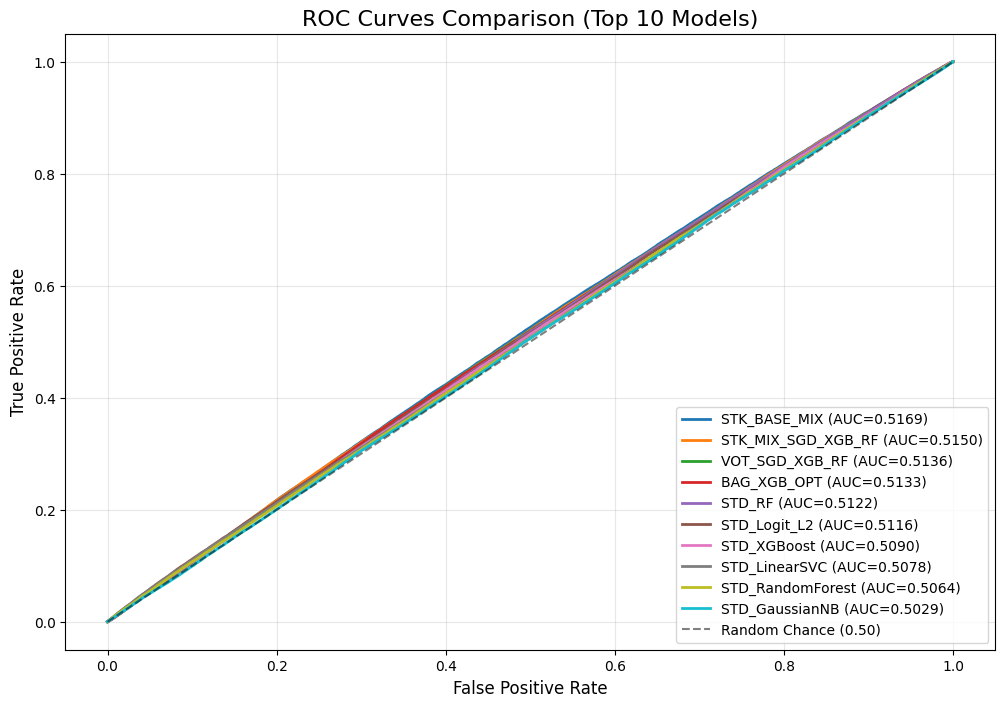

In [101]:
# 1. Setup Validation Data
split_index = 50000
X_eval_plot = X_train.iloc[split_index:].copy()
y_eval_plot = y_train.iloc[split_index:]

# 2. Get Top 10 Models from previous results
df_results = pd.DataFrame(metrics_list).sort_values(by='ROC-AUC', ascending=False)
top_models = df_results.head(10)

plt.figure(figsize=(12, 8))

# 3. Robust Loop: Predict & Plot
for i, row in top_models.iterrows():
    name = row['Model']
    model = results_tracking[name]['best_estimator']
    y_proba = None
    
    # --- Robust Prediction Logic (Same as Evaluation) ---
    try:
        # Attempt 1: Full Features
        X_try = X_eval_plot.copy()
        if hasattr(model, "predict_proba"):
            y_proba = model.predict_proba(X_try)[:, 1]
        else:
            d = model.decision_function(X_try)
            y_proba = (d - d.min()) / (d.max() - d.min())
            
    except Exception:
        try:
            # Attempt 2: Drop Metadata (Date, ID...)
            drop_cols = [c for c in ['DATE', 'TICKER', 'ID'] if c in X_eval_plot.columns]
            X_try = X_eval_plot.drop(columns=drop_cols)
            
            if hasattr(model, "predict_proba"):
                y_proba = model.predict_proba(X_try)[:, 1]
            else:
                d = model.decision_function(X_try)
                y_proba = (d - d.min()) / (d.max() - d.min())
                
        except Exception:
            # Attempt 3: Numeric Only
            drop_cols = [c for c in ['DATE', 'TICKER', 'ID', 'INDUSTRY', 'STOCK'] if c in X_eval_plot.columns]
            X_try = X_eval_plot.drop(columns=drop_cols)
            
            if hasattr(model, "predict_proba"):
                y_proba = model.predict_proba(X_try)[:, 1]
            else:
                d = model.decision_function(X_try)
                y_proba = (d - d.min()) / (d.max() - d.min())

    # 4. Plot Curve if prediction succeeded
    if y_proba is not None:
        fpr, tpr, _ = roc_curve(y_eval_plot, y_proba)
        plt.plot(fpr, tpr, label=f"{name} (AUC={row['ROC-AUC']:.4f})", linewidth=2)

# 5. Finalize Plot
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance (0.50)', alpha=0.5)
plt.title('ROC Curves Comparison (Top 10 Models)', fontsize=16)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.show()

**ROC Curves Analysis**  
The ROC curves for the top 10 models are tightly clustered and barely distinguishable from each other, with all AUC scores ranging narrowly from 0.5029 to 0.5169. This clustering near the random chance baseline (0.50) indicates that all models struggle to discriminate between positive and negative returns, suggesting the classification task is extremely challenging and that the earlier high CV scores may not reflect strong predictive power in terms of class separation.

## IX.3) Best Model Feature Importance

Analyzing features for: STK_BASE_MIX
Ensemble model detected. Displaying base model contributions.


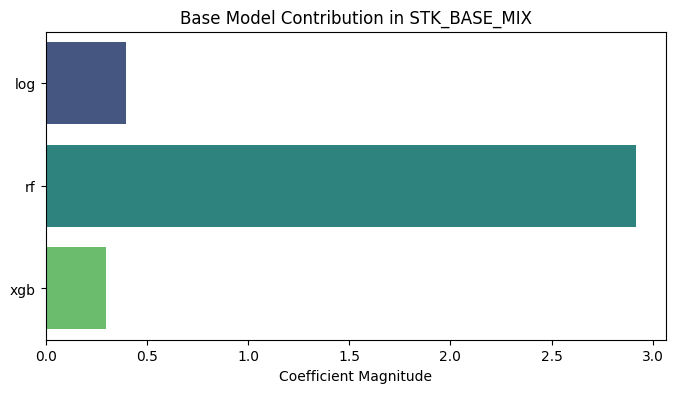

Switching to Random Forest proxy for feature importance visualization.


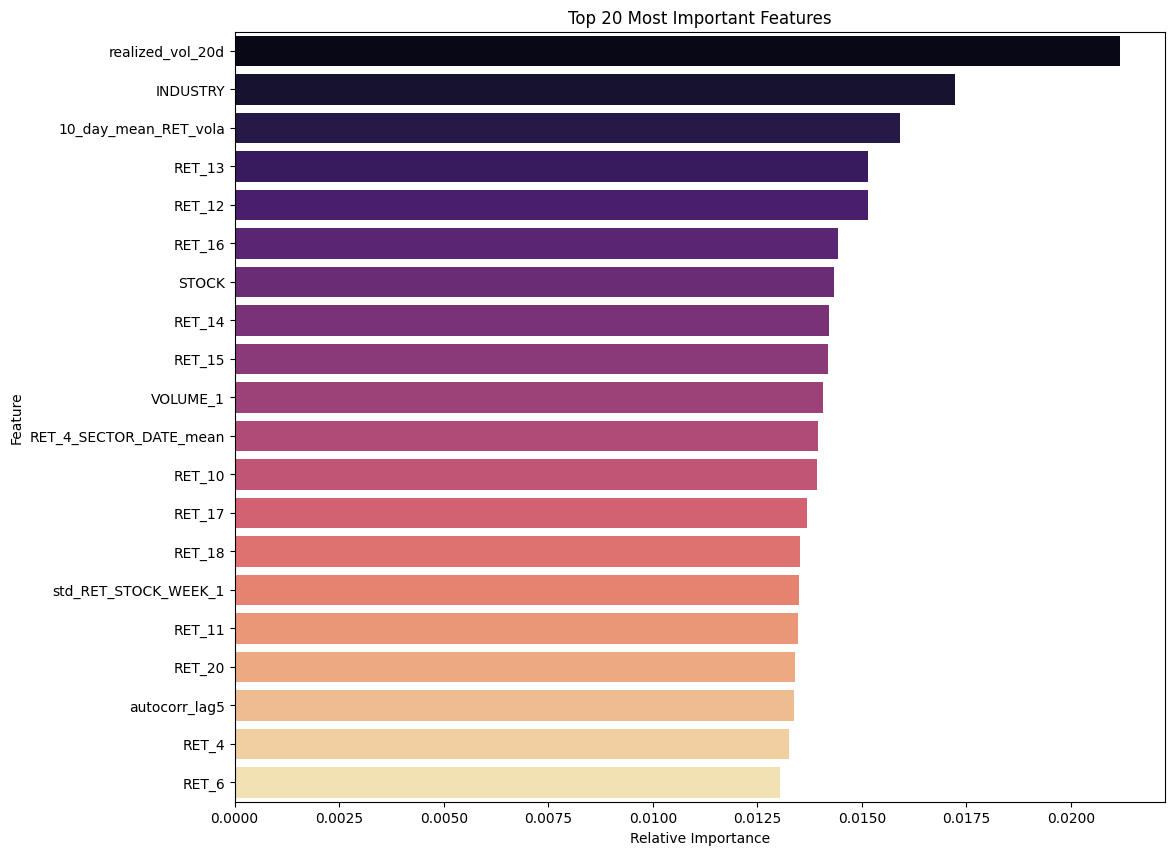

In [ ]:
# 1. Retrieve the winning model
best_model_name = leaderboard.iloc[0]['Model']
best_model = results_tracking[best_model_name]['best_estimator']
feature_names = X_train.columns

print(f"Analyzing features for: {best_model_name}")

# 2. Handle Ensemble Models (Stacking) vs Single Models
importances = None

if hasattr(best_model, 'final_estimator_'):
    # Case: Stacking - Show contribution of base models
    print("Ensemble model detected. Displaying base model contributions.")
    if hasattr(best_model.final_estimator_, 'coef_'):
        meta_importances = np.abs(best_model.final_estimator_.coef_[0])
        meta_names = [est[0] for est in best_model.estimators]
        
        plt.figure(figsize=(8, 4))
        sns.barplot(x=meta_importances, y=meta_names, hue=meta_names, palette='viridis', legend=False)
        plt.title(f"Base Model Contribution in {best_model_name}")
        plt.xlabel("Coefficient Magnitude")
        plt.show()
        
    # Fallback to a proxy model for feature interpretation
    print("Switching to Random Forest proxy for feature importance visualization.")
    if 'STD_RandomForest' in results_tracking:
        proxy_model = results_tracking['STD_RandomForest']['best_estimator']
        importances = proxy_model.feature_importances_
    elif 'STD_XGBoost' in results_tracking:
        proxy_model = results_tracking['STD_XGBoost']['best_estimator']
        importances = proxy_model.feature_importances_

else:
    # Case: Single Model
    if hasattr(best_model, 'feature_importances_'):
        importances = best_model.feature_importances_
    elif hasattr(best_model, 'coef_'):
        importances = np.abs(best_model.coef_[0])

# 3. Plot Feature Importance
if importances is not None:
    # Ensure dimensions match
    limit = min(len(importances), len(feature_names))
    
    feat_imp = pd.DataFrame({
        'Feature': feature_names[:limit],
        'Importance': importances[:limit]
    }).sort_values(by='Importance', ascending=False).head(20)

    plt.figure(figsize=(12, 10))
    sns.barplot(x='Importance', y='Feature', data=feat_imp, hue='Feature', palette='magma', legend=False)
    plt.title('Top 20 Most Important Features')
    plt.xlabel('Relative Importance')
    plt.show()
else:
    print("No feature importance metrics available for this model.")

### Model Interpretation Visualizations

**Base Model Contribution in Stacking Ensemble**  

The meta-learner in the stacking ensemble assigns the highest weight to the Random Forest model (rf), with a coefficient magnitude nearly 3x larger than Logistic Regression (log) and XGBoost (xgb). This indicates the Random Forest's predictions are considered most reliable by the final estimator when combining base model outputs.

**Top 20 Most Important Features**

Volatility measures dominate feature importance, with realized_vol_20d being the most influential predictor. Industry classification (INDUSTRY) and short-term return volatility (10_day_mean_RET_vola) rank highly, followed by multiple return lags (RET_13, RET_12, RET_16) and stock identifiers (STOCK). This pattern shows that risk metrics, sector dynamics, and recent price momentum are the key drivers for predicting future return direction.

## IX.4) Model Prediction Correlation (Heatmap)

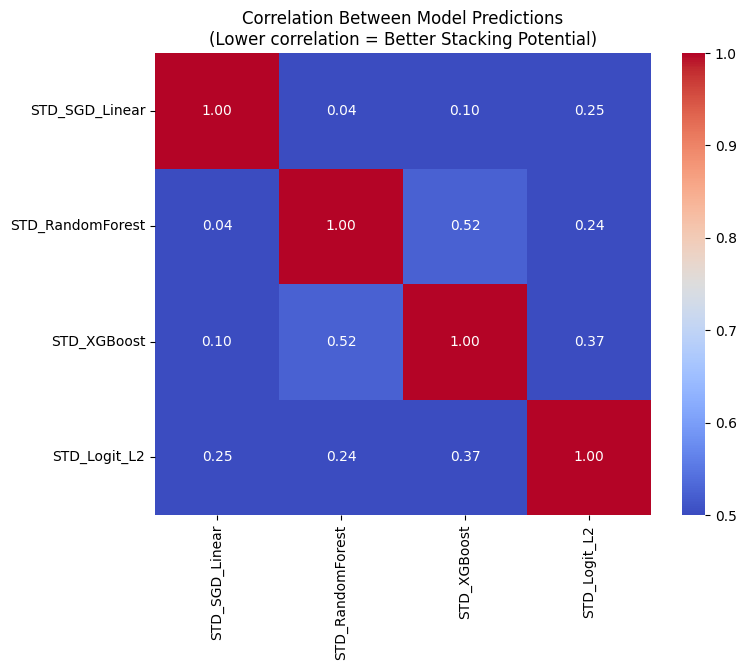

In [ ]:
pred_dict = {}
# Use the same evaluation data as before
split_index = 50000
X_eval_corr = X_train.iloc[split_index:].copy()

# List of models to compare
models_to_compare = ['STD_SGD_Linear', 'STD_RandomForest', 'STD_XGBoost', 'STD_Logit_L2']

for name in models_to_compare:
    if name in results_tracking:
        model = results_tracking[name]['best_estimator']
        try:
            # Try to predict with robustness
            pred_dict[name] = model.predict_proba(X_eval_corr)[:, 1]
        except:
            # Fallback if columns mismatch (remove DATE/ID)
            drop_cols = [c for c in ['DATE', 'ID'] if c in X_eval_corr.columns]
            X_clean = X_eval_corr.drop(columns=drop_cols)
            try:
                pred_dict[name] = model.predict_proba(X_clean)[:, 1]
            except:
                pass

# Create DataFrame
if pred_dict:
    df_preds = pd.DataFrame(pred_dict)
    
    # Plot Heatmap
    plt.figure(figsize=(8, 6))
    corr_matrix = df_preds.corr()
    
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=0.5, vmax=1.0)
    plt.title('Correlation Between Model Predictions\n(Lower correlation = Better Stacking Potential)')
    plt.show()
else:
    print("Could not gather predictions for correlation matrix.")

**Model Prediction Correlation Analysis**  

The correlation heatmap reveals that STD_SGD_Linear shows very low correlation with all other models (0.04-0.25), indicating it makes substantially different predictions. This diversity is ideal for stacking ensembles, as the meta-learner can exploit complementary information. In contrast, STD_RandomForest and STD_XGBoost show moderate correlation (0.52), suggesting they capture similar patterns. The low inter-model correlations overall (mostly below 0.5) explain why ensemble methods have good stacking potential, though they still underperformed the SGD baseline in this case.

## IX.5) Winning Model Confusion Matrix

Generating Confusion Matrix for the winner: STK_BASE_MIX


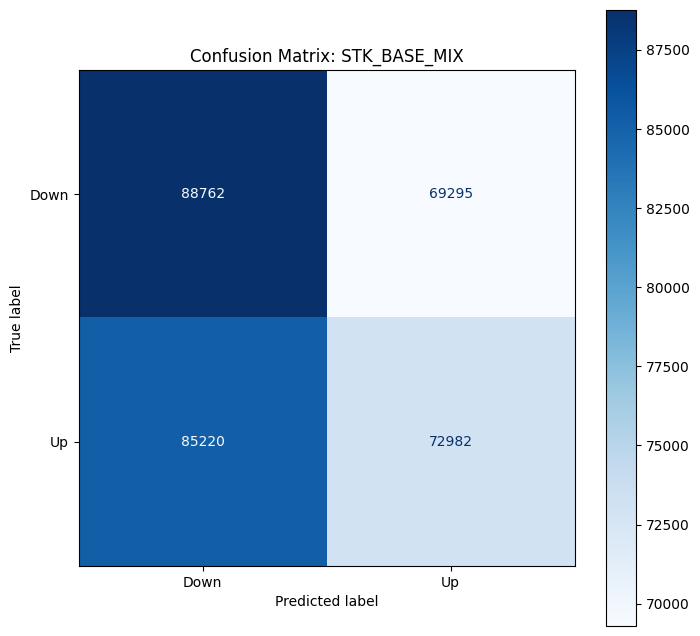

In [ ]:
# 1. Retrieve the best model from the leaderboard
if 'leaderboard' in locals() and not leaderboard.empty:
    best_model_name = leaderboard.iloc[0]['Model']
    print(f"Generating Confusion Matrix for the winner: {best_model_name}")
    
    best_estimator = results_tracking[best_model_name]['best_estimator']
    
    # 2. Prepare validation data (Same split as before)
    split_index = 50000
    X_cm = X_train.iloc[split_index:].copy()
    y_cm = y_train.iloc[split_index:]
    
    # 3. Robust Prediction (Handles DATE/ID column errors)
    y_pred_best = None
    try:
        # Attempt 1: Full data
        y_pred_best = best_estimator.predict(X_cm)
    except Exception:
        # Attempt 2: Drop metadata if error occurs
        try:
            drop_cols = [c for c in ['DATE', 'TICKER', 'ID'] if c in X_cm.columns]
            y_pred_best = best_estimator.predict(X_cm.drop(columns=drop_cols))
        except Exception:
            # Attempt 3: Strict dropping
            drop_cols = [c for c in ['DATE', 'TICKER', 'ID', 'INDUSTRY', 'STOCK'] if c in X_cm.columns]
            y_pred_best = best_estimator.predict(X_cm.drop(columns=drop_cols))
            
    # 4. Plot the Matrix
    if y_pred_best is not None:
        cm = confusion_matrix(y_cm, y_pred_best)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Down', 'Up'])

        # Note: Do not use plt.figure() with disp.plot() as it creates its own figure
        fig, ax = plt.subplots(figsize=(8, 8))
        disp.plot(cmap='Blues', values_format='d', ax=ax)
        plt.title(f'Confusion Matrix: {best_model_name}')
        plt.grid(False) # Remove grid for text readability
        plt.show()
    else:
        print("Error: Could not generate predictions.")

**Confusion Matrix Analysis - STK_BASE_MIX**  

The confusion matrix shows the stacking ensemble's classification performance is barely better than random guessing. The model correctly predicts "Down" movements 88,762 times but misclassifies 69,295 (44% error rate), while for "Up" movements it achieves 72,982 correct predictions with 85,220 false negatives (54% error rate). The near-diagonal balance indicates the model struggles to distinguish between classes, achieving only marginal predictive power despite the ensemble architecture. This poor discrimination aligns with the low AUC scores observed earlier, confirming that the classification task is extremely challenging with the current feature set.

# X) Output for challenge submission

In [109]:
def submit_challenge(model, X, y, X_test):
    
    model.fit(X, y)

    y_pred = model.predict_proba(X_test)[:, 1]

    sub = X_test.copy()
    sub['pred'] = y_pred
    y_pred = sub.groupby('DATE')['pred'].transform(
        lambda x: x > x.median()).values

    submission = pd.Series(y_pred)
    submission.index = X_test_std.index 
    submission.name = "RET"

    submission.to_csv('test.csv', index=True, header=True)

In [110]:
# ensemble_1_estimators = [
#     ('sgd', best_sgd_linear),
#     ('xgb_opt', best_xgb_optimized),
#     ('rf', clf_rf)
# ]

# model = VotingClassifier(
#     estimators=ensemble_1_estimators, 
#     voting='soft', 
#     n_jobs=-1
# )


# stacking_clf_mix = StackingClassifier(
#     estimators=ensemble_1_estimators,
#     final_estimator=LogisticRegression(random_state=42),
#     cv=2,
#     n_jobs=-1
# )

ensemble_base_mix = [
    ('log', clf_log),
    ('rf', clf_rf),
    ('xgb', clf_xgb)
]
stacking_clf_base = StackingClassifier(
    estimators=ensemble_base_mix, 
    final_estimator=LogisticRegression(random_state=42),
    cv=2, 
    n_jobs=-1
)

submit_challenge(stacking_clf_base, X_train, y_train, X_test)